In [1]:
!pip install ripser persim

In [2]:
!pip install gudhi

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import cKDTree
import pandas as pd


from pyproj import Transformer
from ripser import ripser
from persim import plot_diagrams
import gudhi as gd
from pyproj import Transformer

**Limpieza de datos y preprocesamiento**

In [4]:
# importar datos
df_cdmx = pd.read_csv('denue_inegi_09_.csv', encoding='latin1')
df_edo1 = pd.read_csv('denue_inegi_15_1.csv', encoding='latin1')
df_edo2 = pd.read_csv('denue_inegi_15_2.csv', encoding='latin1')

C:\Users\pau_l\AppData\Local\Temp\ipykernel_19276\3156307173.py:2: DtypeWarning: Columns (0: cod_postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cdmx = pd.read_csv('denue_inegi_09_.csv', encoding='latin1')


In [5]:
# Ver cuántos datos hay para sector salud
df_cdmx['codigo_act1_digits'] = df_cdmx['codigo_act'].astype(str).str[:2]
df_edo1['codigo_act2_digits'] = df_edo1['codigo_act'].astype(str).str[:2]
df_edo2['codigo_act3_digits'] = df_edo2['codigo_act'].astype(str).str[:2]

df_cdmx['codigo_act1_digits'].value_counts()

codigo_act1_digits
46    210168
81     67363
72     57721
62     22841
31     17908
43     13458
54     11058
61     10448
52     10226
33      7090
32      6822
56      5295
53      4981
71      4862
93      3517
48      2491
23      1480
51      1430
49       831
22       511
55       184
11        45
21        31
Name: count, dtype: int64

In [6]:
df_edo1['codigo_act2_digits'].value_counts()

codigo_act2_digits
46    396591
31     45783
43     18966
33     16391
32     13159
53      7780
52      7566
54      5984
48      2164
22      1680
51      1583
23      1203
49       781
11       258
21       111
Name: count, dtype: int64

In [7]:
df_edo2['codigo_act3_digits'].value_counts()

codigo_act3_digits
81    122568
72     94042
62     31260
61     19753
71      8977
56      8498
93      6209
54      5389
55        19
Name: count, dtype: int64

La primer base de datos, del Estado de México no contiene el sector 62, por lo que unicámente se utilizara df_edo2.

In [8]:
df_cdmx.shape

(460761, 43)

In [9]:
# filtrar los primeros dos dígitos para 62
df_cdmx = df_cdmx[df_cdmx['codigo_act1_digits'].str[:2] == '62']
df_edo2 = df_edo2[df_edo2['codigo_act3_digits'].str[:2] == '62']

print(df_cdmx.shape)
print(df_edo2.shape)

(22841, 43)
(31260, 43)


In [10]:
# Join df_cdmx and df_edo2
df_metropolitana = pd.concat([df_cdmx, df_edo2])

df_metropolitana.head()

df_metropolitana.shape

(54101, 44)

In [11]:
df_metropolitana = df_metropolitana.drop(columns=['codigo_act1_digits', 'codigo_act3_digits'])
df_metropolitana.head()

,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,...,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
304457,11822253,09015621411000053000061236S6,MARIE STOPES CONDESA,FUNDACION MARIE STOPES MEXICO AC,621411,Centros de planificación familiar del sector p...,11 a 30 personas,CALLE,Atlixco,AVENIDA,...,Cuauhtémoc ...,1182,2,5.560513e+09,MAYRA.CRUZ@MARIESTOPES.ORG.MX,WWW.MARIESTOPES.ORG.MX,Fijo,19.415518,-99.172861,2025-04
304458,6795800,09013621511000421000003549S7,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,GRUPO DIAGNOSTICO MEDICO PROA SA DE CV,621511,Laboratorios médicos y de diagnóstico del sect...,0 a 5 personas,CALLE,PASEO DE LA VIRGEN,CALLE,...,Xochimilco ...,0014,15,NaN,INFORMES.WEB@CHOPO.COM.MX,WWW.CHOPO.COM.MX,Fijo,19.280340,-99.137950,2017-03
304459,8485187,09015624191001661000000000S0,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS...,DAMIAN INIESTRA ANTUNEZ AC,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,CALLE,LUDWING VAN BEETHOVEN,CALLE,...,Cuauhtémoc ...,0023,11,5.587393e+09,NaN,NaN,Fijo,19.460542,-99.131678,2019-11
304460,767683,09005624191000011001000000U0,1ER DISTRITO AREA NORTE DE ALCOHOLICOS ANONIMOS,ALCOHOLICOS ANONIMOS AC,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,CALLE,306,CALLE,...,Gustavo A. Madero ...,1186,15,NaN,NaN,NaN,Fijo,19.492214,-99.087259,2010-07
304461,11366041,09017621211005831000000000U0,20 DENTAL,NaN,621211,Consultorios dentales del sector privado,0 a 5 personas,CALLE,CERAMICA,CALLE,...,Venustiano Carranza ...,0282,25,NaN,NaN,NaN,Fijo,19.440626,-99.107722,2024-11


In [12]:
# Explorar datos
df_metropolitana.info()

<class 'pandas.DataFrame'>
Index: 54101 entries, 304457 to 64918
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          54101 non-null  int64  
 1   clee        54101 non-null  str    
 2   nom_estab   54101 non-null  str    
 3   raz_social  11909 non-null  str    
 4   codigo_act  54101 non-null  int64  
 5   nombre_act  54101 non-null  str    
 6   per_ocu     54101 non-null  str    
 7   tipo_vial   54101 non-null  str    
 8   nom_vial    54100 non-null  str    
 9   tipo_v_e_1  54101 non-null  str    
 10  nom_v_e_1   54099 non-null  str    
 11  tipo_v_e_2  54101 non-null  str    
 12  nom_v_e_2   54099 non-null  str    
 13  tipo_v_e_3  54101 non-null  str    
 14  nom_v_e_3   54084 non-null  str    
 15  numero_ext  50667 non-null  float64
 16  letra_ext   25476 non-null  str    
 17  edificio    8778 non-null   str    
 18  edificio_e  8725 non-null   str    
 19  numero_int  24675 non-null  float64


In [13]:
print(df_metropolitana['entidad'].value_counts())
print(df_metropolitana['municipio'].value_counts().head(20))

entidad
México              31260
Ciudad de México    22841
Name: count, dtype: int64
municipio
Iztapalapa              3377
Ecatepec de Morelos     3373
Gustavo A. Madero       2682
Cuauhtémoc              2660
Nezahualcóyotl          2417
Toluca                  2281
Benito Juárez           2075
Tlalpan                 1702
Tlalnepantla de Baz     1686
Miguel Hidalgo          1622
Naucalpan de Juárez     1582
Coyoacán                1503
Álvaro Obregón          1487
Cuautitlán Izcalli      1156
Metepec                  989
Venustiano Carranza      963
Atizapán de Zaragoza     950
Azcapotzalco             890
Iztacalco                827
Tecámac                  817
Name: count, dtype: int64


In [14]:
df_metropolitana['entidad'].value_counts()

entidad
México              31260
Ciudad de México    22841
Name: count, dtype: int64

Para este proyecto en particular se necesitarán las coordenadas geográficas, el código del sector y la entidad. Por lo mismo, a continuación se hara un filtro para tener unicámente las columnas indicadas.

In [15]:
df_analisis = df_metropolitana[['entidad', 'codigo_act', 'latitud', 'longitud']]

df_analisis.head()

,entidad,codigo_act,latitud,longitud
304457,Ciudad de México,621411,19.415518,-99.172861
304458,Ciudad de México,621511,19.280340,-99.137950
304459,Ciudad de México,624191,19.460542,-99.131678
304460,Ciudad de México,624191,19.492214,-99.087259
304461,Ciudad de México,621211,19.440626,-99.107722


In [16]:
df_analisis.shape

(54101, 4)

In [17]:
df_analisis.info()

<class 'pandas.DataFrame'>
Index: 54101 entries, 304457 to 64918
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   entidad     54101 non-null  str    
 1   codigo_act  54101 non-null  int64  
 2   latitud     54101 non-null  float64
 3   longitud    54101 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 2.1 MB


In [18]:
df_analisis.isna().sum()

entidad       0
codigo_act    0
latitud       0
longitud      0
dtype: int64

Una vez filtrando los datos, no hay ningún valor nulo. Teniendo esta base de datos, es posible realizar una exploración de los datos y realizar visualizaciones iniciales.

**Visualización descriptiva inicial**


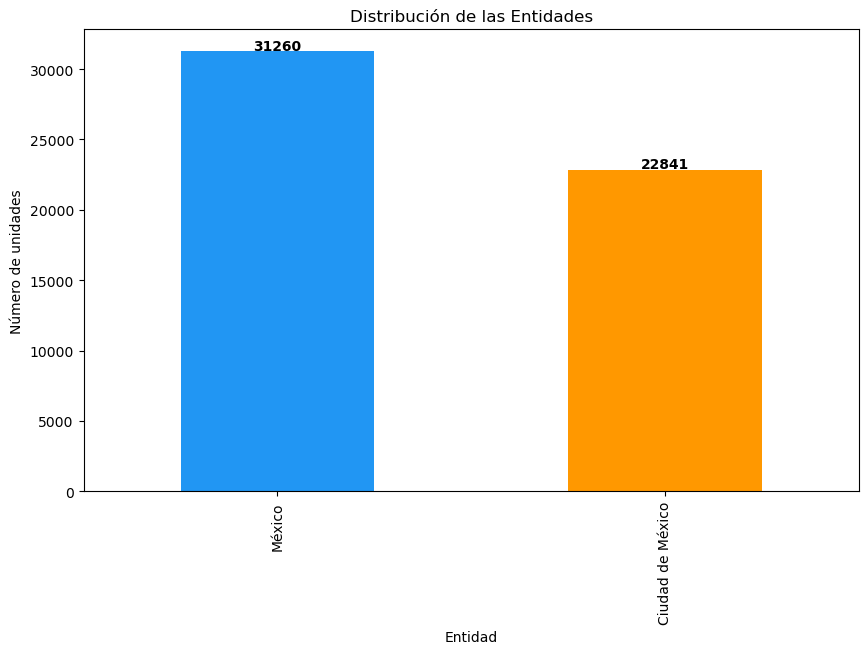

In [19]:
# Bar plot distribución CDMX y EDOMEX
plt.figure(figsize=(10, 6))
df_metropolitana['entidad'].value_counts().plot(kind='bar', color=['#2196F3', '#FF9800'])
plt.title('Distribución de las Entidades')
plt.xlabel('Entidad')
plt.ylabel('Número de unidades')
# escribir total en bar plot
for i, v in enumerate(df_metropolitana['entidad'].value_counts()):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.show()

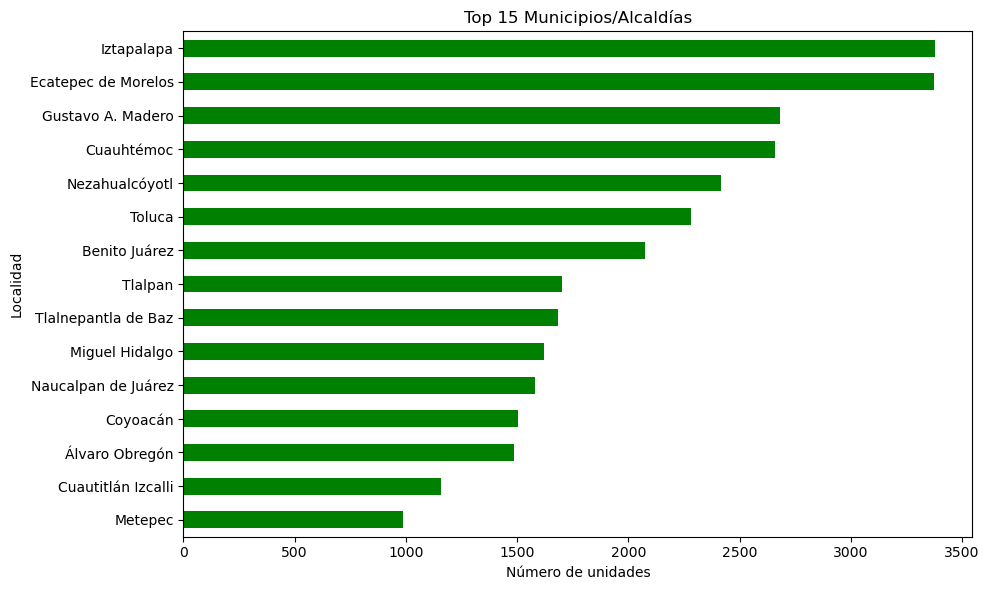

Text(0.5, 1.0, '15 Municipios/Alcaldías con menos establecimientos')

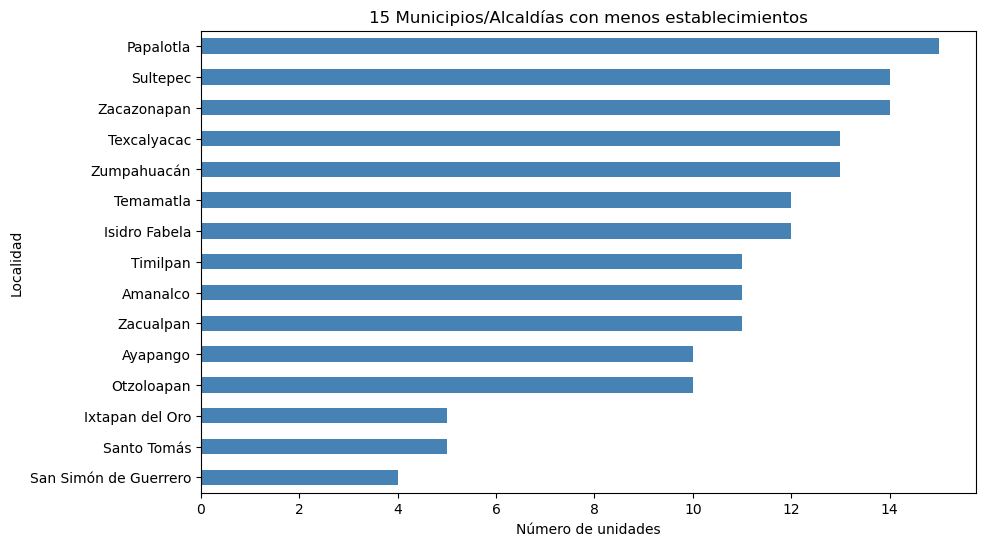

In [20]:
# Ver el top 15 municipios con más establecimientos.
df_metropolitana['municipio'].value_counts().head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Top 15 Municipios/Alcaldías')
plt.xlabel('Número de unidades')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

# Ver los 15 municipios y alcaldías con menos consultoríos en sector salud.
df_metropolitana['municipio'].value_counts().tail(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='steelblue', edgecolor='none')
plt.ylabel('Localidad')
plt.xlabel('Número de unidades')
plt.title('15 Municipios/Alcaldías con menos establecimientos')

En particular se puede observar como es que en el top 15 de alcaldías o municipios, se encuentran en su mayoría todas las alcaldías de la Ciudad de México. Mientras que en la gráfica de municipios con menos establecimientos, todos son municipios del Estado de México. Esto puede ser un indicador de que en la capital hay más consultorios o establecimientos dedicados al sector salud.

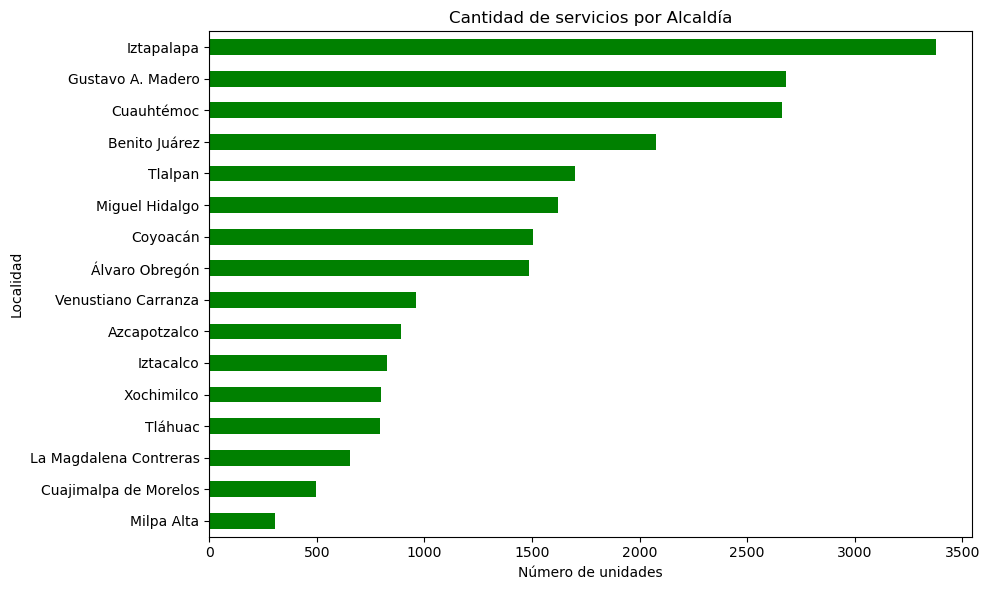

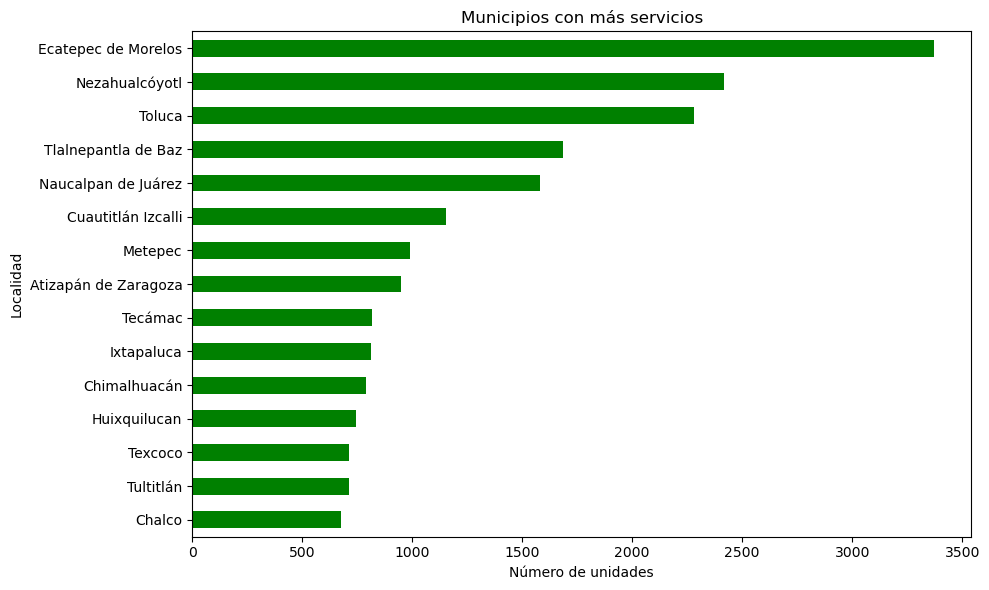

Text(0.5, 1.0, '15 Municipios con menos establecimientos')

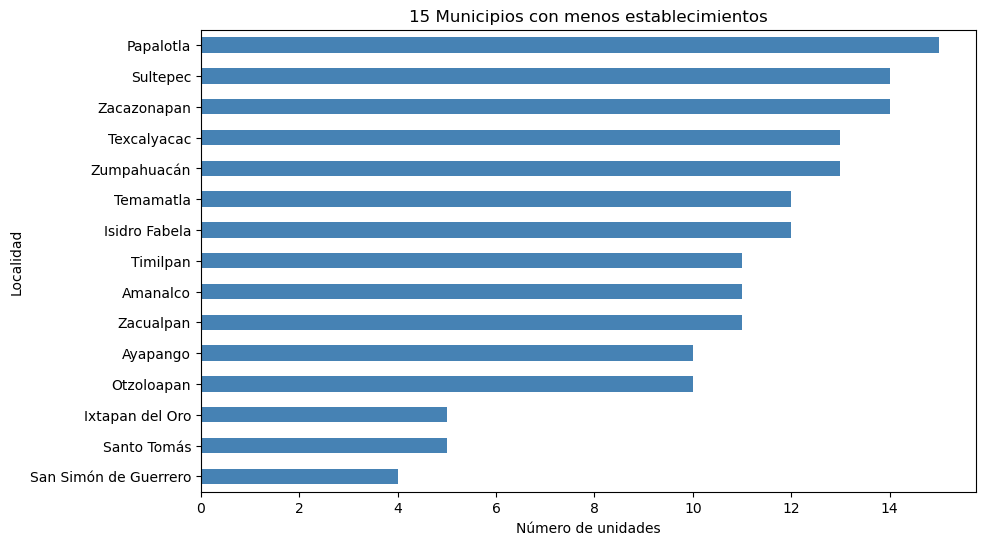

In [21]:
df_cdmx = df_metropolitana[df_metropolitana['entidad'] == 'Ciudad de México']
df_edomex = df_metropolitana[df_metropolitana['entidad'] == 'México']

# Municipios con más establecimientos.
df_cdmx['municipio'].value_counts().sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Cantidad de servicios por Alcaldía')
plt.xlabel('Número de unidades')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

# Municipios con más establecimientos.
df_edomex['municipio'].value_counts().head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Municipios con más servicios')
plt.xlabel('Número de unidades')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

df_edomex['municipio'].value_counts().tail(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='steelblue', edgecolor='none')
plt.ylabel('Localidad')
plt.xlabel('Número de unidades')
plt.title('15 Municipios con menos establecimientos')

**CDMX**
Las alcaldías como menos servicios médicos, son Táhuac, Magdalena Conteras y Milpa Alta. Mientras que en Izatapalapa, Gustavo A. Madero, y Cuáhtemoc son las que más tienen.

**EDOMEX**
Los municipios con más servicios con Ecatepec, Nexahualcóyotl y Toluca. Mientras, que los que tienen menos son: Ixtapan del Oro, Santo Tomás y San Simón de Guerrero.

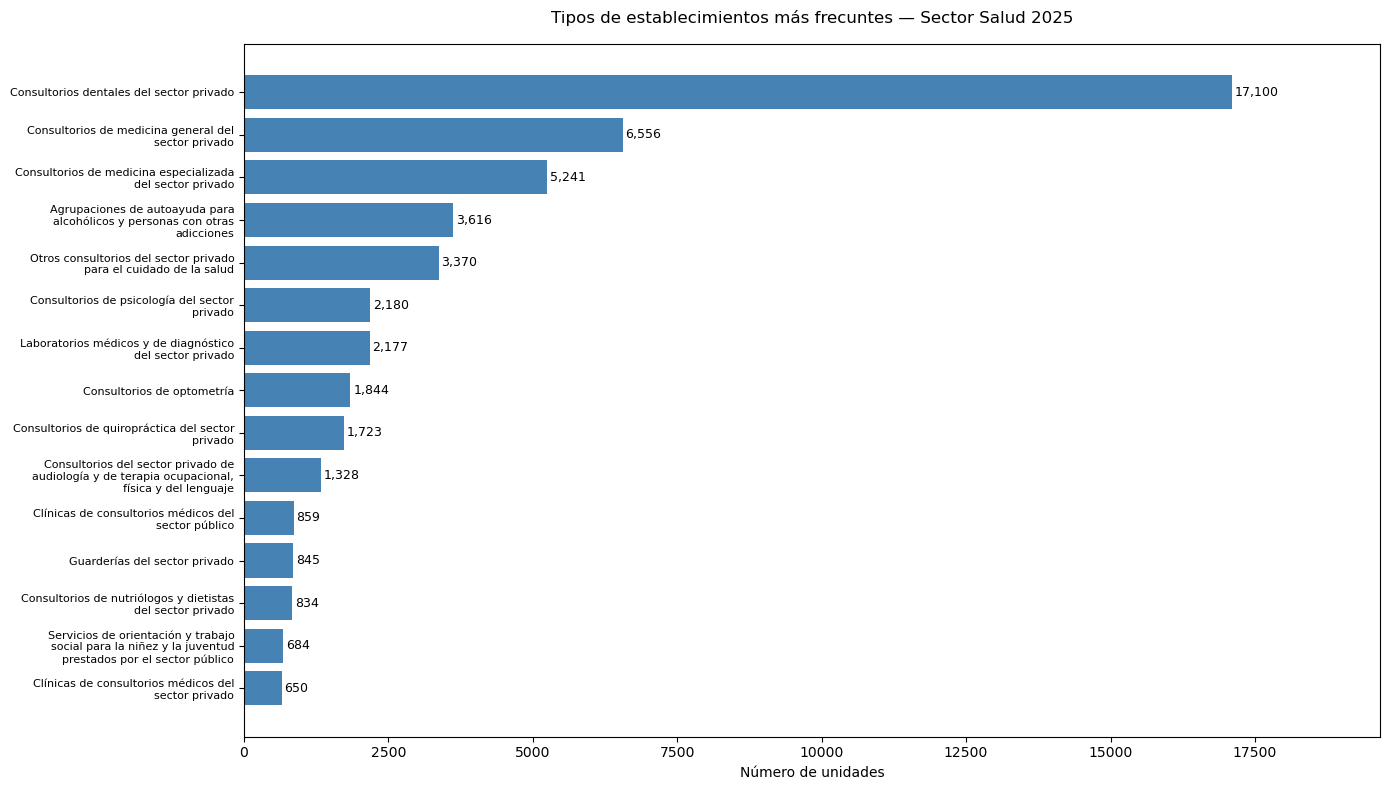

In [22]:
# Gráfica para tipos de establecimiento
fig, ax = plt.subplots(figsize=(14, 8))

top_act = (df_metropolitana.groupby(['codigo_act', 'nombre_act'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=True)
           .tail(15))

bars = ax.barh(range(len(top_act)), top_act['n'], color='steelblue', edgecolor='none')

# Etiquetas cortas — solo el valor al final de la barra
for bar, val in zip(bars, top_act['n']):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

# Nombres en el eje Y con wrap automático
import textwrap
etiquetas = [textwrap.fill(nombre, width=40) for nombre in top_act['nombre_act']]
ax.set_yticks(range(len(top_act)))
ax.set_yticklabels(etiquetas, fontsize=8)

ax.set_title('Tipos de establecimientos más frecuntes — Sector Salud 2025', fontsize=12, pad=15)
ax.set_xlabel('Número de unidades')
ax.margins(x=0.15)  # espacio para los números al final

plt.tight_layout()
plt.show()

En este caso se puede observar que, en su mayoría, las entidades son privadas, a excepción de una clínica de consultorios médicos. Asimismo, se puede observar que los consultorios dentales privados son los que predominan alrededor de la zona metropolitana.


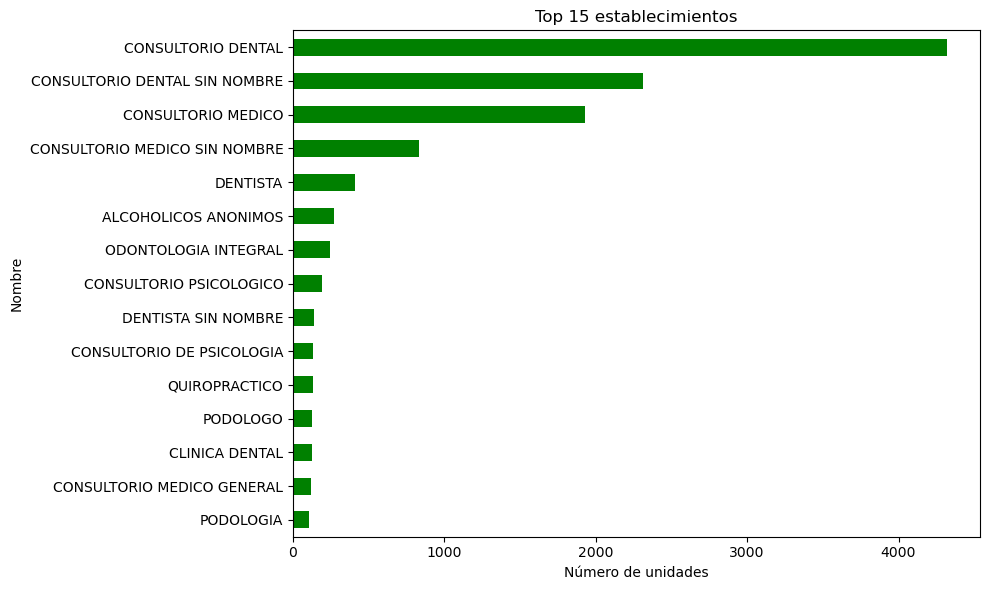

In [23]:
# Top 15 establecimientos plot
df_metropolitana['nom_estab'].value_counts().head(15).sort_values().plot(
    kind='barh', figsize=(10, 6), color='green', edgecolor='none')
plt.title('Top 15 establecimientos')
plt.xlabel('Número de unidades')
plt.ylabel('Nombre')
plt.tight_layout()
plt.show()

La mayoría de los establecimientos son dentales, de psicología, podología, quiroprácticos y establecimientos para alcohólicos anónimos. Dentro del top 15 de establecimientos médicos, hay consultorios médicos y generales. Es decir, abundan más los establecimientos enfocados al cuidado de la salud mental y lo dental.

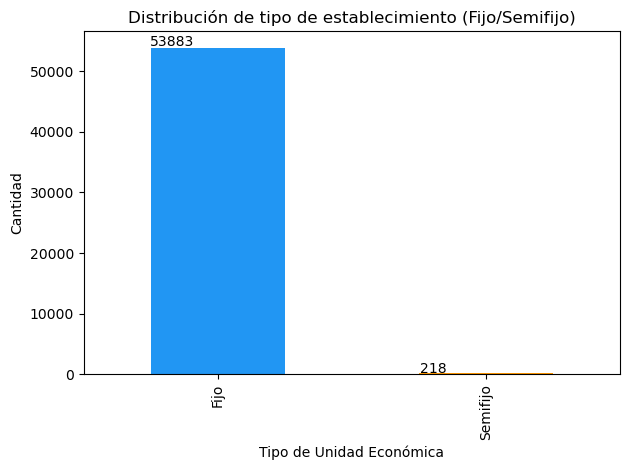

In [24]:
# Bar Plot tipoUniEco
ax = df_metropolitana['tipoUniEco'].value_counts().plot(kind='bar',
                                                     color=['#2196F3', '#FF9800'])
plt.title('Distribución de tipo de establecimiento (Fijo/Semifijo)')
plt.xlabel('Tipo de Unidad Económica')
plt.ylabel('Cantidad')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
plt.tight_layout()
plt.show()

La gráfica muestra cómo es que los establecimientos fijos son más predominantes que los semifijos, lo que sugiere que en su mayoría los consultorios, están de manera permanente, haciendo que haya una cantidad confiable de servicios médicos en la zona, sin riesgo a que estos dejen de existir o que su estancia sea temporal.

Antes de hacer la construcción de complejos simpliciales, es importante observar si existen duplicados.

In [25]:
df_analisis.duplicated().sum()

np.int64(5452)

In [26]:
# encontrar duplicados
df_metropolitana.duplicated().sum()

np.int64(0)

En este caso, es posible observar que cada una de las filas registradas en la base de datos es diferente. Sin embargo, existen casos en donde los establecimientos están en una misma ubicación. Dado que el siguiente paso es hacer complejos simpliciales de Čech/Vietoris-Rips para explorar la conectividad en función de distancias entre puntos, las distancias para estos establecimientos en particular serán cero. Por ende, se considera que, dado el número de datos que hay, se eliminarán los duplicados de la base de datos.

In [27]:
# Antes
print(df_metropolitana.shape)

# Quitar coordenadas duplicadas
df_metropolitana = df_metropolitana.drop_duplicates(subset=['latitud', 'longitud'])

# Después
print(f"Puntos eliminados: {54101 - len(df_metropolitana)}")

(54101, 42)
Puntos eliminados: 8199


In [28]:
df_cdmx = df_metropolitana[df_metropolitana['entidad'] == 'Ciudad de México']
df_edomex = df_metropolitana[df_metropolitana['entidad'] == 'México']

print(f"CDMX:   {len(df_cdmx)} puntos únicos")
print(f"EdoMex: {len(df_edomex)} puntos únicos")

CDMX:   17596 puntos únicos
EdoMex: 28306 puntos únicos


Debido a la magnitud de los datos, se opta por tomar un muestreo, en dónde de manera aleatoria se selecciona el 10% de establecimientos de cada municipio.

In [29]:
# Muestra estratificada por municipio/alcaldía
def muestra_proporcional(df, frac=0.30, min_n=4):
    return (df
        .groupby('municipio', group_keys=False)
        .apply(lambda x: x.sample(n=max(min_n, int(len(x) * frac)),
                                   random_state=42)))

df_cdmx_muestra   = muestra_proporcional(df_cdmx)
df_edomex_muestra = muestra_proporcional(df_edomex)
print(f"CDMX muestra:   {len(df_cdmx_muestra)}")
print(f"EdoMex muestra: {len(df_edomex_muestra)}")


CDMX muestra:   5273
EdoMex muestra: 8456


##  Construcción de Complejos Simpliciales

In [30]:
# Convertimos lat/lon a metros (UTM)
# para que las librerías puedan medir bien las distancias

transformer = Transformer.from_crs(
    "EPSG:4326",   # WGS84
    "EPSG:32614",  # UTM zona 14N (CDMX/EdoMex)
    always_xy=True
)

def convertir_a_utm(df):

    x, y = transformer.transform(
        df['longitud'].values,
        df['latitud'].values
    )

    points = np.column_stack((x, y))

    return points

In [31]:
# Combinar muestras
df_muestra = pd.concat([
    df_cdmx_muestra,
    df_edomex_muestra
])

# Transformador WGS84 -> UTM zona 14N
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32614",
    always_xy=True
)

# Convertir coordenadas
x, y = transformer.transform(
    df_muestra['longitud'].values,
    df_muestra['latitud'].values
)

# Matriz de puntos
points = np.column_stack((x, y))

print(points.shape)

points_cdmx = convertir_a_utm(df_cdmx_muestra) # convertir coordenadas CDMX

points_edomex= convertir_a_utm(df_edomex_muestra) # convertir coordenadas EDOMEX

print("CDMX:", points_cdmx.shape)
print("EdoMex:", points_edomex.shape)

(13729, 2)
CDMX: (5273, 2)
EdoMex: (8456, 2)


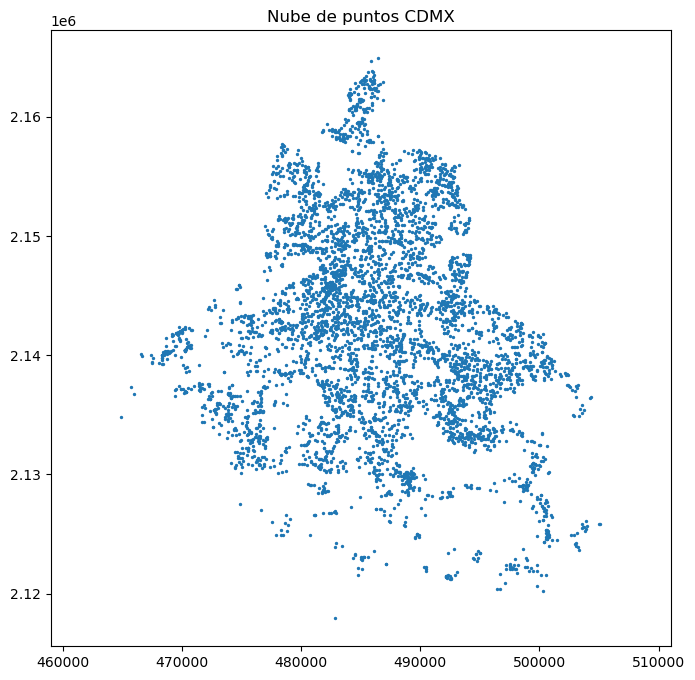

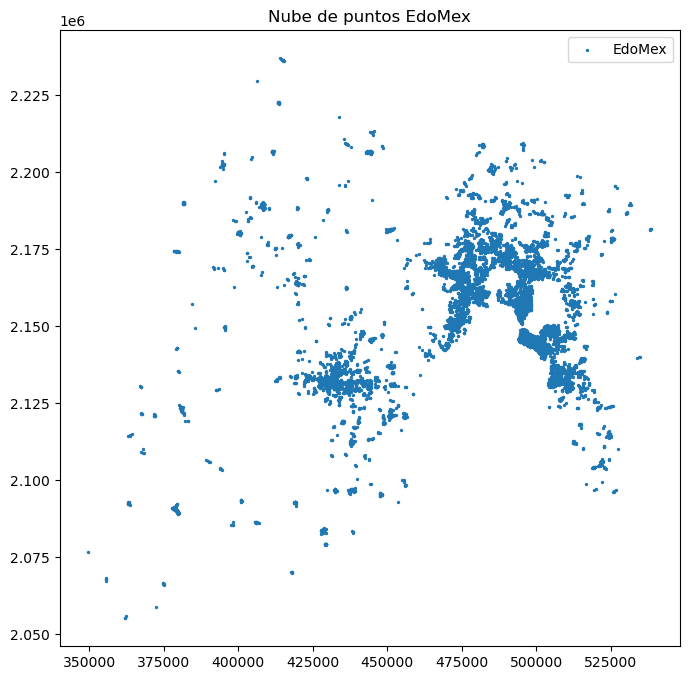

In [32]:
# Visaulizar los establecimientos en CDMX y EDOMEX

plt.figure(figsize=(8,8))

plt.scatter(
    points_cdmx[:,0],
    points_cdmx[:,1],
    s=2,
    label='CDMX'
)

plt.title("Nube de puntos CDMX")
plt.axis('equal')
plt.show()


plt.figure(figsize=(8,8))

plt.scatter(
    points_edomex[:,0],
    points_edomex[:,1],
    s=2,
    label='EdoMex'
)

plt.title("Nube de puntos EdoMex")
plt.legend()
plt.show()


De manera inicial se puede observar como es que al norte de la Ciudad de México hay más establecimientos que al sur. En el caso de EDOMEX, las localidades se concentran más en el oriente.

A continuación se construiran los complejos de Vitrois-Rips. Para ello, se probaran una lista de diversos parámetros para la distancia máxima que puede tener una arista. De esta manera será posible medir la conectividad que hay en las zonas dependiendo de la distancia que haya entre los establecimientos.


================ CDMX ================


Resumen CDMX


,radio,vertices,simplices
0,500,5273,93664
1,1000,5273,701428
2,1500,5273,2673187
3,2000,5273,7160051
4,3000,5273,29404620



================ EdoMex ================


Resumen EdoMex


,radio,vertices,simplices
0,500,8456,152122
1,1000,8456,951378
2,1500,8456,2914292
3,2000,8456,6771848
4,3000,8456,22839961


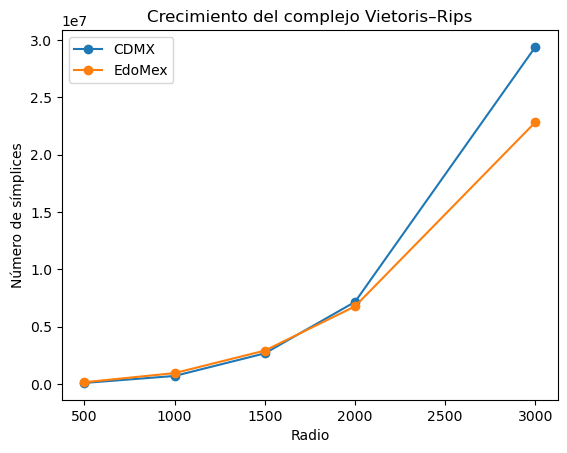

In [33]:

# ------------------------------------------------------------
# Radios a probar (en metros)
# ------------------------------------------------------------

radios = [500, 1000, 1500, 2000, 3000]

# ============================================================
# CDMX
# ============================================================

resultados_cdmx = []

print("\n================ CDMX ================\n")

for r in radios:

    # Construcción del complejo
    rips_cdmx = gd.RipsComplex(
        points=points_cdmx,
        max_edge_length=r
    )

    # max_dimension=2
    simplex_tree_cdmx = rips_cdmx.create_simplex_tree(
        max_dimension=2
    )

    # Información del complejo
    n_vertices = simplex_tree_cdmx.num_vertices()
    n_simplices = simplex_tree_cdmx.num_simplices()

    # Guardar resultados
    resultados_cdmx.append({
        "radio": r,
        "vertices": n_vertices,
        "simplices": n_simplices
    })

# Convertir a DataFrame
df_resultados_cdmx = pd.DataFrame(resultados_cdmx)

print("\nResumen CDMX")
display(df_resultados_cdmx)

# ============================================================
# EdoMex
# ============================================================

resultados_edomex = []

print("\n================ EdoMex ================\n")

for r in radios:
    # Construcción del complejo
    rips_edomex = gd.RipsComplex(
        points=points_edomex,
        max_edge_length=r
    )

    simplex_tree_edomex = rips_edomex.create_simplex_tree(
        max_dimension=2
    )

    # Información del complejo
    n_vertices = simplex_tree_edomex.num_vertices()
    n_simplices = simplex_tree_edomex.num_simplices()

    # Guardar resultados
    resultados_edomex.append({
        "radio": r,
        "vertices": n_vertices,
        "simplices": n_simplices
    })

# Convertir a DataFrame
df_resultados_edomex = pd.DataFrame(resultados_edomex)

print("\nResumen EdoMex")
display(df_resultados_edomex)


plt.plot(df_resultados_cdmx['radio'],
         df_resultados_cdmx['simplices'],
         marker='o',
         label='CDMX')

plt.plot(df_resultados_edomex['radio'],
         df_resultados_edomex['simplices'],
         marker='o',
         label='EdoMex')

plt.xlabel("Radio")
plt.ylabel("Número de símplices")
plt.title("Crecimiento del complejo Vietoris–Rips")
plt.legend()
plt.show()



En primer lugar se observa que el número de complejos simpliciales de CDMX es mayor al de EDOMEX, sugieriendo que hay mayor conectividad en la capital. Por otro lado, la gráfica muestra como es que el crecimiento de construcción de simplejos, para EDOMEX, es más lenta que el de la Ciudad de México.

En particular, se opta por tomar un radio de 2 km, ya que el el radio donde el complejo empieza a conectarse significativamente sin, hacerlo completamente.

Una vez decido esto, es posible contruir los complejos para un solo radio. Cabe destacar que en este caso, se tomará la dimensión máxima de 2, ya que se buscan explorar los huecos y cavidades. Al tener una mayor dimensión sería más complejo de visualizar.

In [34]:
print(df_resultados_cdmx[df_resultados_cdmx['radio'] == 2000])
print(df_resultados_edomex[df_resultados_edomex['radio'] == 2000])

   radio  vertices  simplices
3   2000      5273    7160051
   radio  vertices  simplices
3   2000      8456    6771848


In [35]:
# ------------------------------------------------------------
# CDMX
# ------------------------------------------------------------

result_cdmx = ripser(
    points_cdmx,
    maxdim=2,
    thresh=2000
)

diagrams_cdmx = result_cdmx['dgms']

# ------------------------------------------------------------
# EDOMEX
# ------------------------------------------------------------

result_edomex = ripser(
    points_edomex,
    maxdim=2,
    thresh=2000
)

diagrams_edomex = result_edomex['dgms']

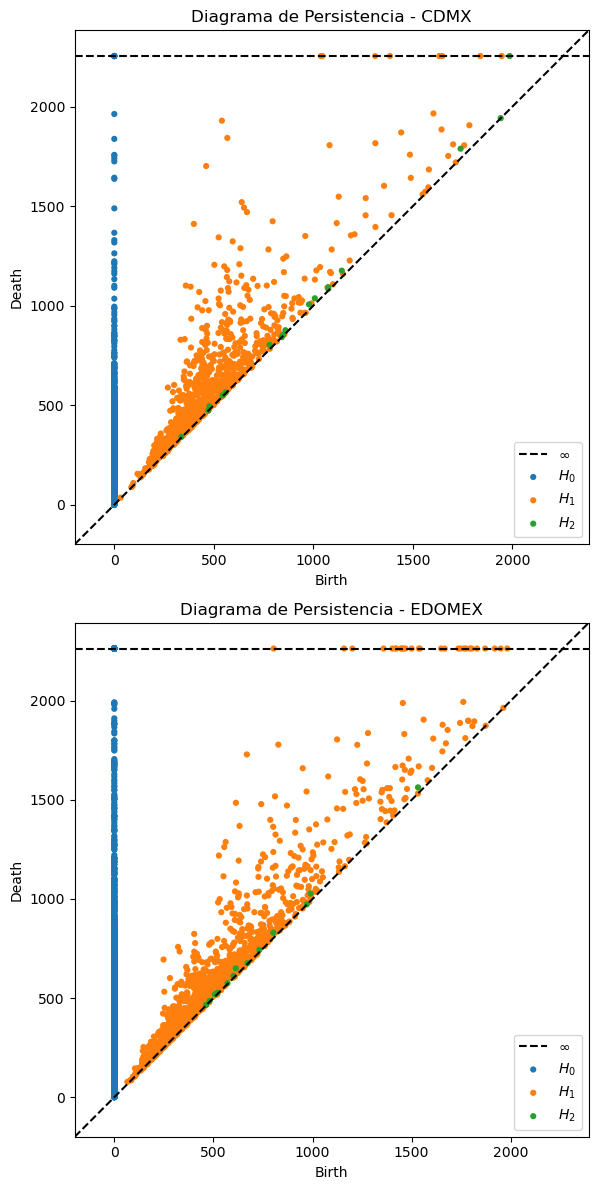

In [36]:

# ============================================================
#  DIAGRAMAS DE PERSISTENCIA
# ============================================================

plt.figure(figsize=(8, 12))

plt.subplot(2, 1, 1)
plot_diagrams(
    diagrams_cdmx,
    show=False
)
plt.title("Diagrama de Persistencia - CDMX")

plt.subplot(2, 1, 2)
plot_diagrams(
    diagrams_edomex,
    show=False
)
plt.title("Diagrama de Persistencia - EDOMEX")
plt.tight_layout()
plt.show()

In [37]:
def contar_infinitos(diagrams):
    for i, dgm in enumerate(diagrams):
        infinitos = (dgm[:, 1] == np.inf).sum()
        print(f"H{i}: {infinitos}")

print("=== CDMX ===")
contar_infinitos(diagrams_cdmx)

print("\n=== EdoMex ===")
contar_infinitos(diagrams_edomex)

=== CDMX ===
H0: 6
H1: 8
H2: 1

=== EdoMex ===
H0: 200
H1: 27
H2: 0


**CDMX**
Para la Ciudad de México, se observa que dentro de los puntos que persisten más hay seis componente conexa, 8 huecos de dimensión una y una cavidad. Igualmente, se observa que dentro del rango de 1500 y 2000 hay, algunas componentes conexas, huecos y cavidades. Sin embargo, estos mueren en un punto en específico.

Basado en esto, se infiere que hay 8 zonas en la Ciudad de México donde la cobertura a 2 km persenta huecos, sugiriendo acceso límitado. De igual manera, se encontró que existe una cavidad, significando, también una límitante en la distribución de servicios médicos en la capital.

**EDOMEX**
En cuanto al Estado de México se observa que hay 200 componente conexa y alrededror de 27 huecos de dimensión uno, que persisten. Por lo tanto, existen municipios en el estado, que cuentan con un nivel bajo de servicios médicos, lo que repercute en el acceso a la salud de las personas. Sin embargo, es importante mencionar, que en este caso, no hay ninguna cavidad que persiste.

Así como se observo en el análisis inicial, la capital tiene mayor conectividad que el Estado de México, lo que sugiere que los habitantes de esta CDMX tienen mayor acceso.

c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\gudhi\persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Figure size 1000x500 with 0 Axes>

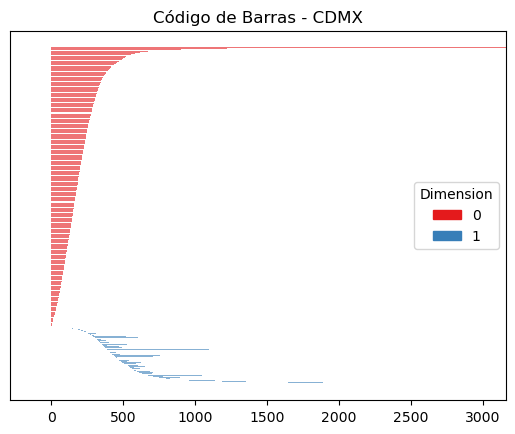

<Figure size 1000x500 with 0 Axes>

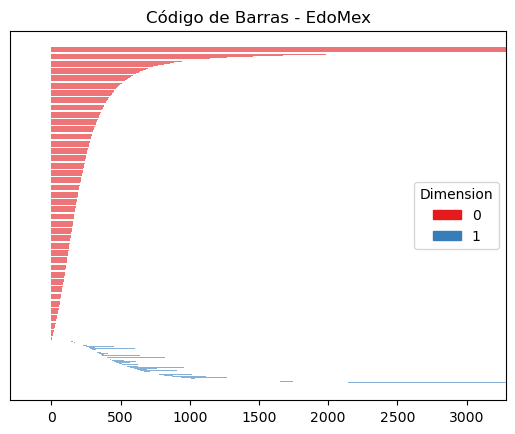

In [38]:
# Calcular persistencia con GUDHI
simplex_tree_cdmx.compute_persistence()
simplex_tree_edomex.compute_persistence()

# Barcodes
plt.figure(figsize=(10, 5))
gd.plot_persistence_barcode(simplex_tree_cdmx.persistence(), legend=True)
plt.title("Código de Barras - CDMX")
plt.show()

plt.figure(figsize=(10, 5))
gd.plot_persistence_barcode(simplex_tree_edomex.persistence(), legend=True)
plt.title("Código de Barras - EdoMex")
plt.show()

**CDMX**
Observando el código de barras, se confirma el hecho de que solo perstiste una sola componente conexa en la ciudad, lo que quiere decir los establecimientos de la ciudad forman una red conectada en un radio de 2km. De igual manera se observa, que persisten algunos huecos, lo que significa que existen areás de la ciudad, en dónde la población tiene que viajar a distancias más grandes, para poder tener acceso de salud.

Lo cual es consistente con lo encontrado anteriormente, dónde se observo que hay zonas, en la ciudad, como en el suroeste (Cuajimalpa de Morelos, Magdalena Contresas y Milpa Alta) , dónde hay menos servicios.

**EDOMEX**
En este caso, se observa que hay barras que tardan más en conectarse. Sin, embargo, de igual manera se observa que tienen más huecos. Esto podría indicar que existe una desigualdad, respecto a la distribución de servicios médicos, ya que mientras unos se encuentran conectados, hay otros lugar dónde no hay servicio.

Anteriormente, se había observado, que existe más puntos dentro de la zona oriente, por lo que se puede inferir que las zonas de menor acceso, son los municipios del poniente, cómo el municipio de Santo Tomás o San Simón de Guerrero.

Una vez teniendo una perspectiva general de lo que sucede en CDMX y EDOMEX, se hara un análisis similar, pero fijando los códigos 621 y 622, ya que estos contienen servicios médicos de consulta externa y servicios relacionados, y hospitales.

# Análisis solo para Hospitales y Consultorios externos

In [39]:
df_metropolitana['codigo_act'].astype(str).str[:3].value_counts()

codigo_act
621    36965
624     7378
622      847
623      712
Name: count, dtype: int64

In [40]:
hospitales = df_metropolitana[df_metropolitana['codigo_act'].astype(str).str[:3] == '622']
consultorios = df_metropolitana[df_metropolitana['codigo_act'].astype(str).str[:3] == '621']


# Separar por entidad
hosp_cdmx = hospitales[hospitales['entidad'] == 'Ciudad de México']
hosp_edomex = hospitales[hospitales['entidad'] == 'México']

cons_cdmx = consultorios[consultorios['entidad'] == 'Ciudad de México']
cons_edomex = consultorios[consultorios['entidad'] == 'México']

print(f"Hospitales CDMX: {len(hosp_cdmx)}")
print(f"Consultorios CDMX: {len(cons_cdmx)}")
print(f"Hospitales EDOMEX: {len(hosp_edomex)}")
print(f"Consultorios EDOMEX: {len(cons_edomex)}")

Hospitales CDMX: 343
Consultorios CDMX: 13835
Hospitales EDOMEX: 504
Consultorios EDOMEX: 23130


Existen más consultorios médicos en la zona metropolitana que hospitales, por lo que surge la hipótesis de que los consultorios solventan la falta de hospitales en los huecos existentes.

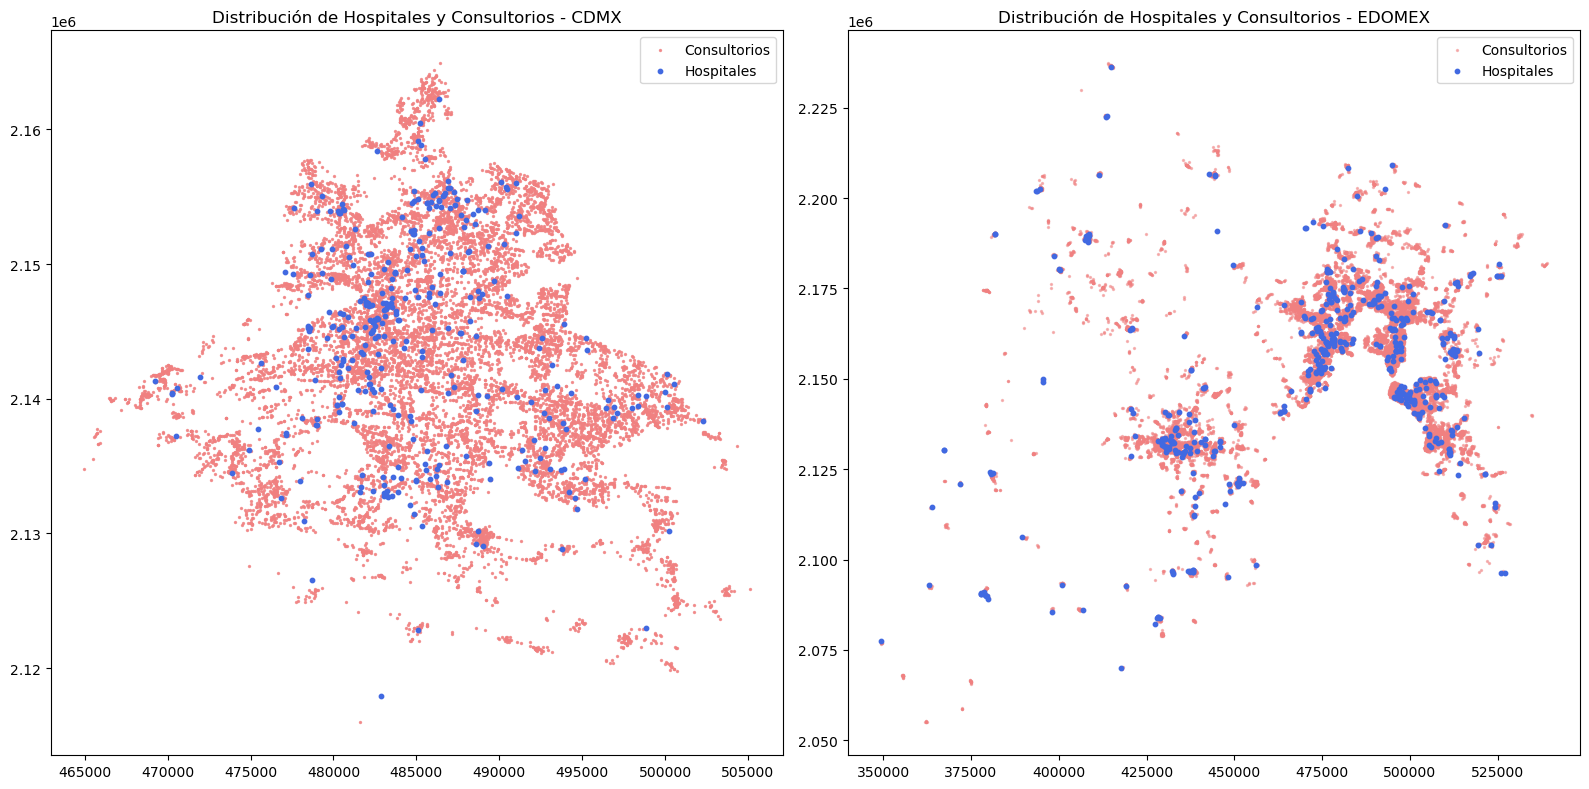

In [41]:
# Convertir a UTM
points_hosp_cdmx = convertir_a_utm(hosp_cdmx)
points_hosp_edomex = convertir_a_utm(hosp_edomex)

points_cons_cdmx = convertir_a_utm(cons_cdmx)
points_cons_edomex = convertir_a_utm(cons_edomex)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].scatter(points_cons_cdmx[:,0], points_cons_cdmx[:,1], s=2, c='lightcoral', label='Consultorios', alpha=0.8)
axes[0].scatter(points_hosp_cdmx[:,0], points_hosp_cdmx[:,1], s=10, c='royalblue', label='Hospitales')
axes[0].set_title("Distribución de Hospitales y Consultorios - CDMX")
axes[0].legend()

axes[1].scatter(points_cons_edomex[:,0], points_cons_edomex[:,1], s=2, c='lightcoral', label='Consultorios', alpha=0.5)
axes[1].scatter(points_hosp_edomex[:,0], points_hosp_edomex[:,1], s=10, c='royalblue', label='Hospitales')
axes[1].set_title("Distribución de Hospitales y Consultorios - EDOMEX")
axes[1].legend()

plt.tight_layout()
plt.show()

Visualmente, se puede notar cómo es que existen más servicios médicos de consulta externa y servicios relacionado que hospitales. Sin embargo, persisten los espacios en blanco, que se encontraron en el análisis anterior. Por lo que, a pesar de que los consultorios, puedan llegar a satisfacer la demanda médica en ciertas zonas, aún así existen zonar que continuan teniendo una falta de servicios médicos.

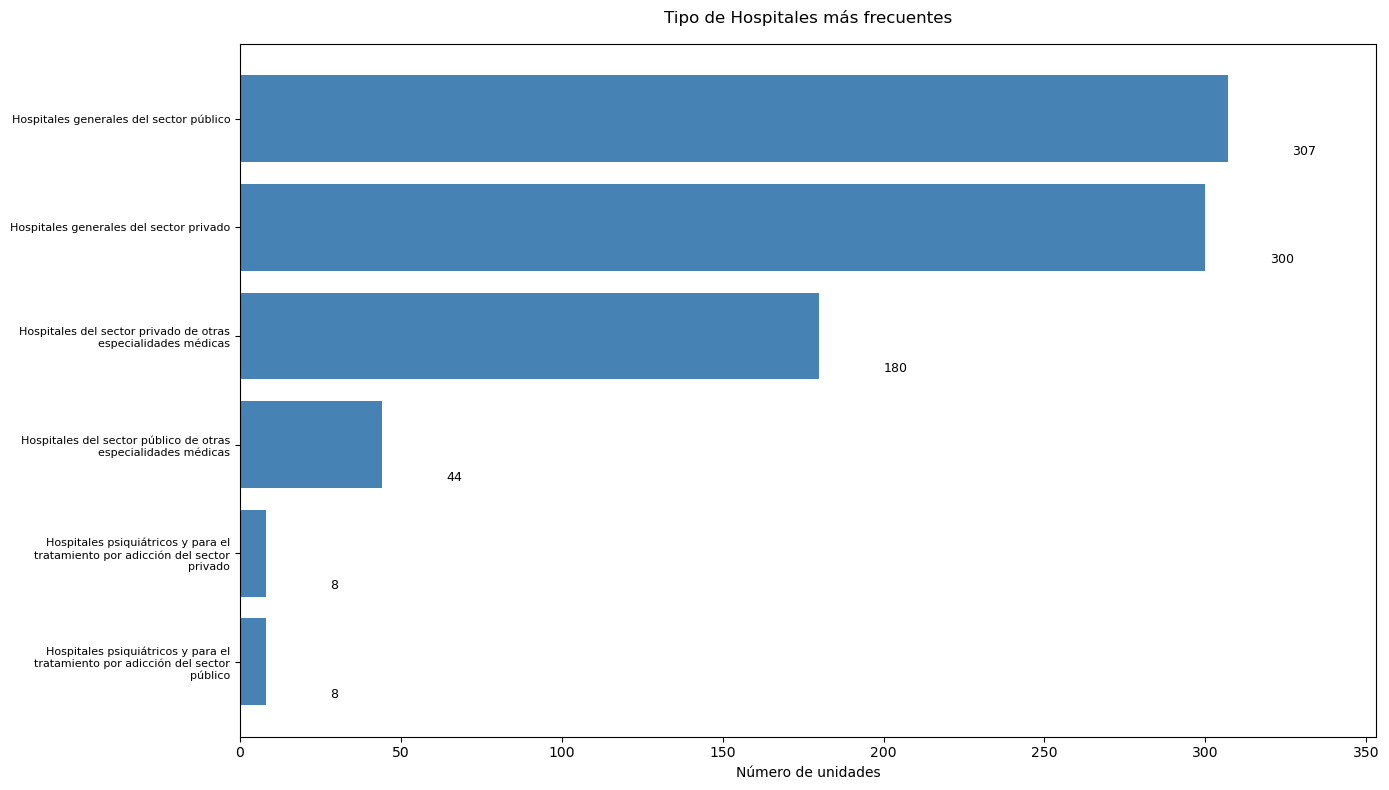

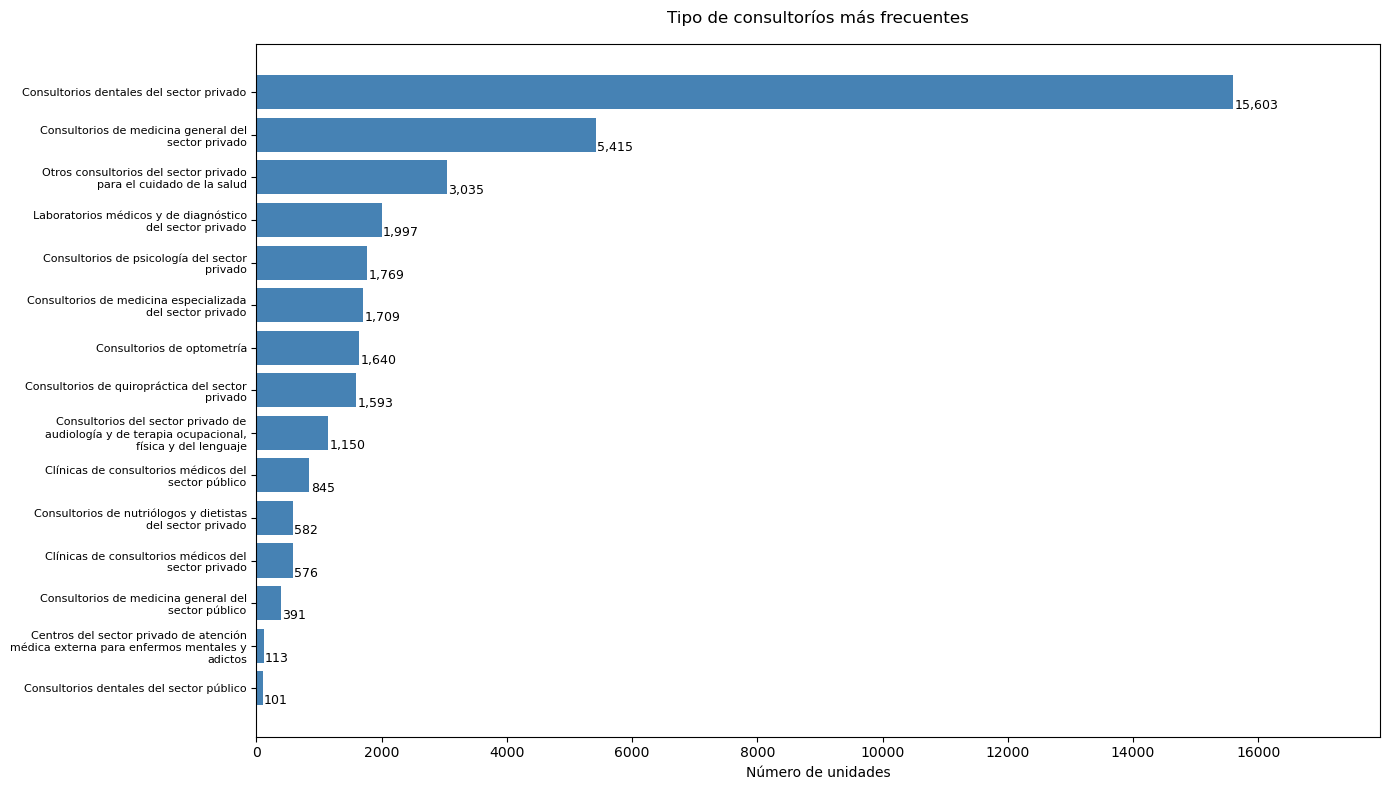

In [42]:
# Top 15 hospitales
# Gráfica para tipos de establecimiento
fig, ax = plt.subplots(figsize=(14, 8))

top_act = (hospitales.groupby(['codigo_act', 'nombre_act'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=True)
           .tail(15))

bars = ax.barh(range(len(top_act)), top_act['n'], color='steelblue', edgecolor='none')

# Etiquetas cortas — solo el valor al final de la barra
for bar, val in zip(bars, top_act['n']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/8,
            f'{val:,}', va='center', fontsize=9)

# Nombres en el eje Y con wrap automático
import textwrap
etiquetas = [textwrap.fill(nombre, width=40) for nombre in top_act['nombre_act']]
ax.set_yticks(range(len(top_act)))
ax.set_yticklabels(etiquetas, fontsize=8)

ax.set_title('Tipo de Hospitales más frecuentes', fontsize=12, pad=15)
ax.set_xlabel('Número de unidades')
ax.margins(x=0.15)  # espacio para los números al final

plt.tight_layout()
plt.show()

# Top 15 consultoríos
# Gráfica para tipos de establecimiento
fig, ax = plt.subplots(figsize=(14, 8))

top_act = (consultorios.groupby(['codigo_act', 'nombre_act'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=True)
           .tail(15))

bars = ax.barh(range(len(top_act)), top_act['n'], color='steelblue', edgecolor='none')

# Etiquetas cortas — solo el valor al final de la barra
for bar, val in zip(bars, top_act['n']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/8,
            f'{val:,}', va='center', fontsize=9)

# Nombres en el eje Y con wrap automático
import textwrap
etiquetas = [textwrap.fill(nombre, width=40) for nombre in top_act['nombre_act']]
ax.set_yticks(range(len(top_act)))
ax.set_yticklabels(etiquetas, fontsize=8)

ax.set_title('Tipo de consultoríos más frecuentes', fontsize=12, pad=15)
ax.set_xlabel('Número de unidades')
ax.margins(x=0.15)  # espacio para los números al final

plt.tight_layout()
plt.show()

En el caso de los hospitales, no es determinante si es del sector privado o público, ya que hay 3 tipos de establecimiento que son públicos y otros 3 privados. Sin embargo, en el caso de los consultoríos, es posibles observar que la mayoría de estos son privados.

Una vez teniendo esta información, es posible realizar complejos simpliciales que permitan analizar sí la hipótesis se satisface.

In [43]:
print(cons_edomex.groupby('municipio').size().min())
print(cons_edomex.groupby('municipio').size().sort_values().head(10))

1
municipio
Ixtapan del Oro          1
San Simón de Guerrero    3
Otzoloapan               4
Santo Tomás              4
Texcalyacac              6
Ecatzingo                6
Zacualpan                6
Temamatla                7
Ayapango                 8
Timilpan                 8
dtype: int64


In [44]:
# Hospitales y consultorios por alcaldía/municipio
hosp_por_municipio_cdmx = hosp_cdmx['municipio'].value_counts().rename('hospitales')
cons_por_municipio_cdmx = cons_cdmx['municipio'].value_counts().rename('consultorios')

hosp_por_municipio_edomex = hosp_edomex['municipio'].value_counts().rename('hospitales')
cons_por_municipio_edomex = cons_edomex['municipio'].value_counts().rename('consultorios')

# Combinar en un DataFrame — municipios sin hospitales
df_cdmx_dist = pd.concat([hosp_por_municipio_cdmx, cons_por_municipio_cdmx], axis=1).fillna(0).astype(int)
df_edomex_dist = pd.concat([hosp_por_municipio_edomex, cons_por_municipio_edomex], axis=1).fillna(0).astype(int)

# Ver municipios sin hospitales
print("CDMX sin hospitales:")
print(df_cdmx_dist[df_cdmx_dist['hospitales'] == 0])

print("\nEdoMex sin hospitales:")
print(df_edomex_dist[df_edomex_dist['hospitales'] == 0])

CDMX sin hospitales:
Empty DataFrame
Columns: [hospitales, consultorios]
Index: []

EdoMex sin hospitales:
                         hospitales  consultorios
municipio                                        
Xonacatlán                        0           132
Ocoyoacac                         0           121
Melchor Ocampo                    0            90
Ozumba                            0            56
Juchitepec                        0            50
Xalatlaco                         0            40
Tonatico                          0            34
Amatepec                          0            30
Morelos                           0            30
Nopaltepec                        0            25
San José del Rincón               0            25
Tenango del Aire                  0            20
Jilotzingo                        0            18
Villa de Allende                  0            17
Soyaniquilpan de Juárez           0            16
Joquicingo                        0        

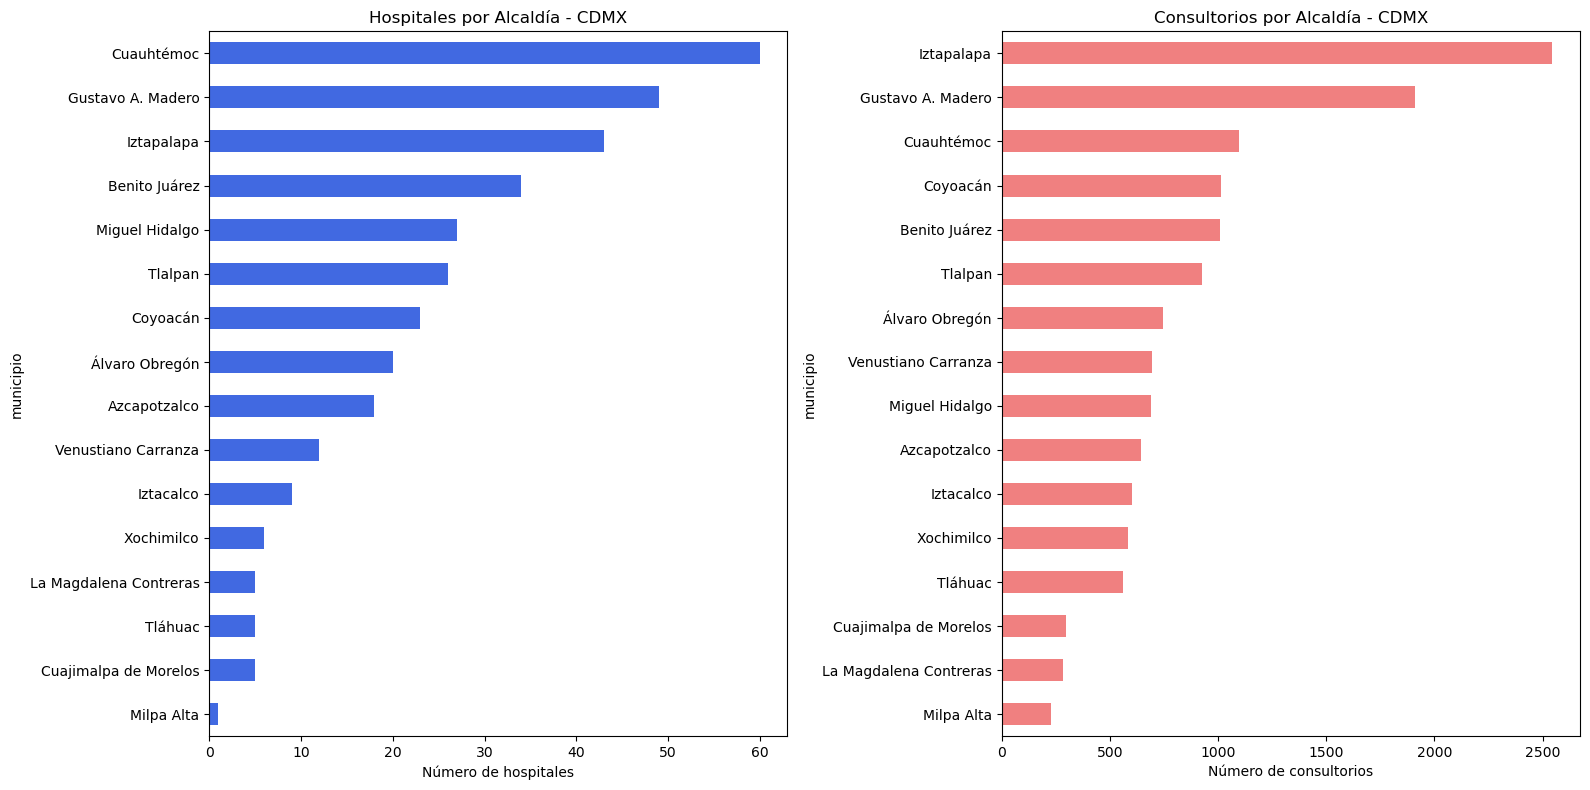

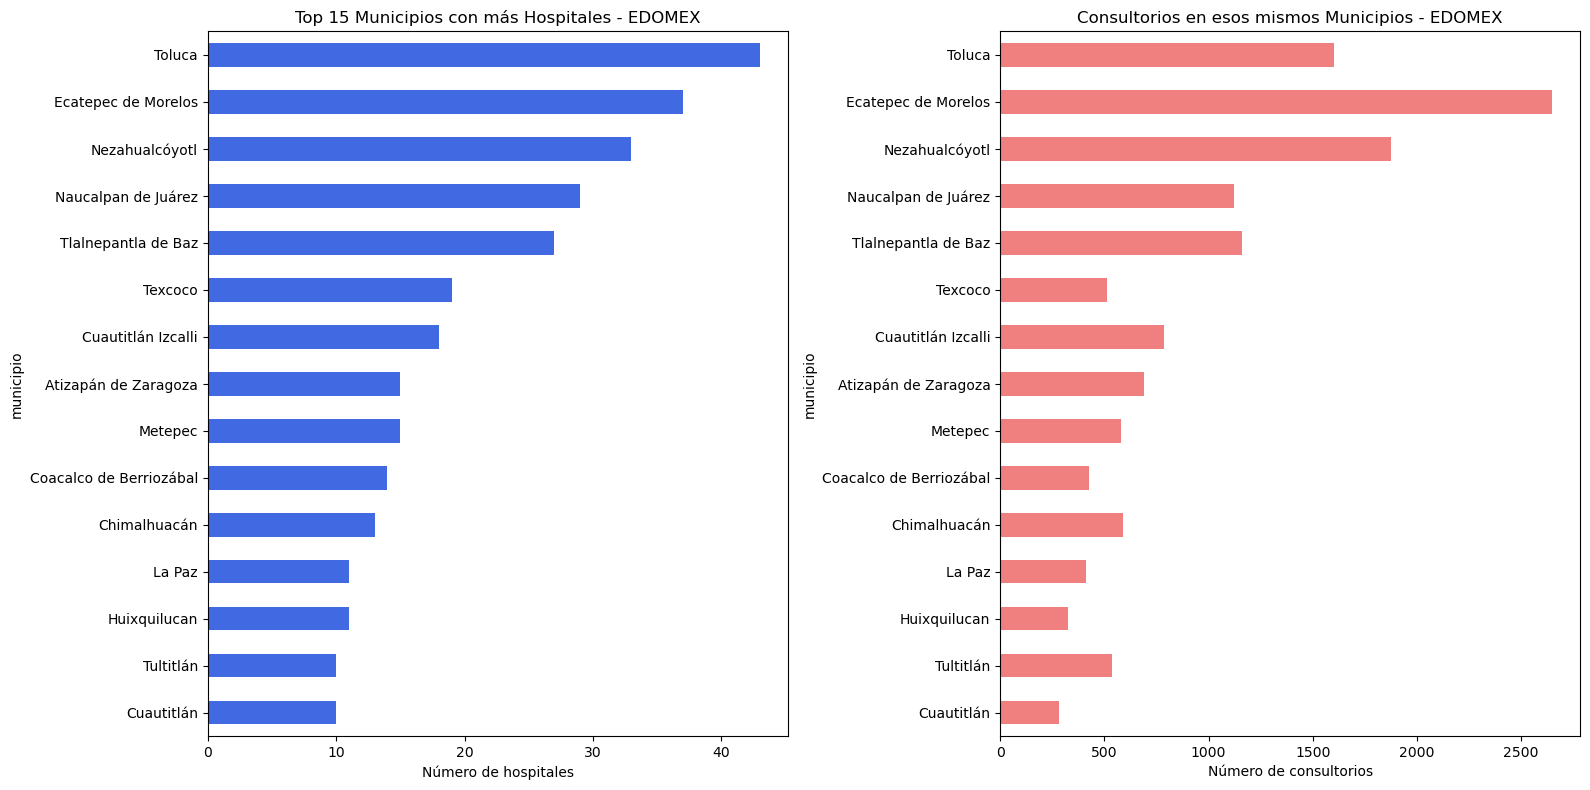

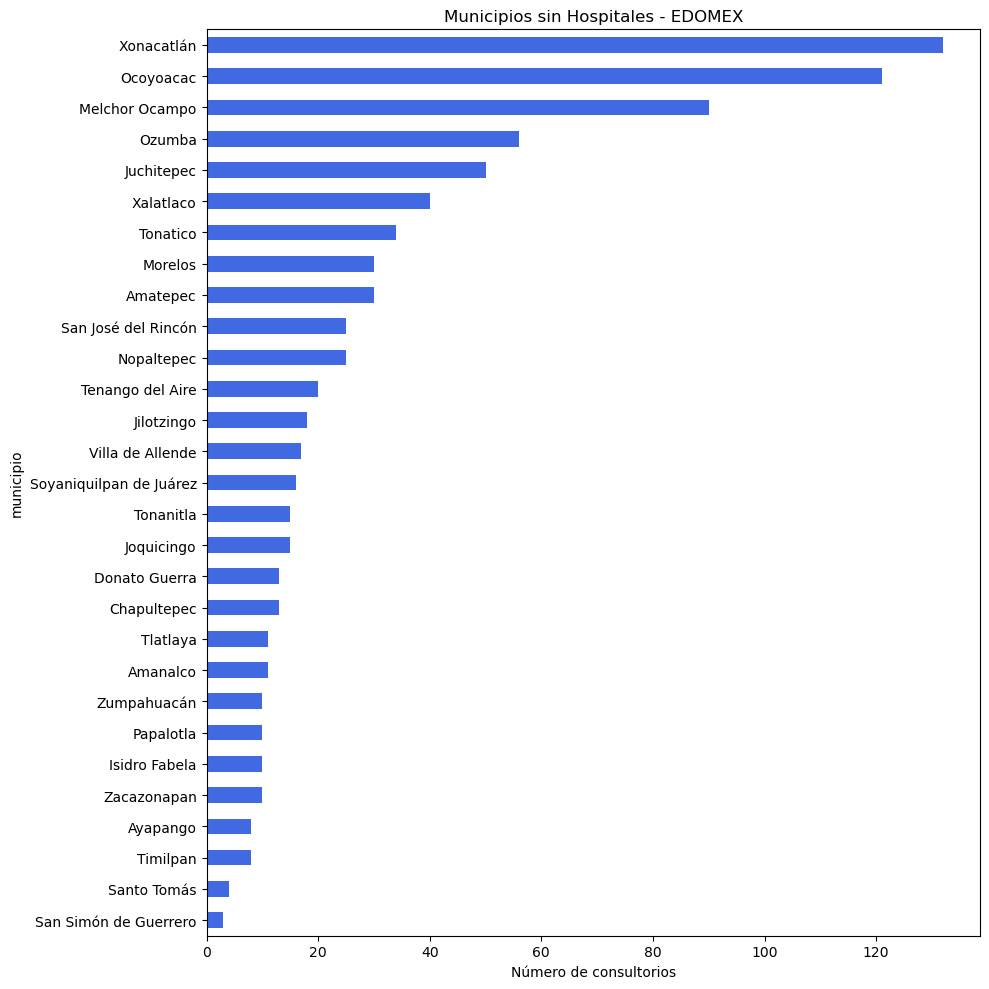

In [45]:
# ver numero hospitales y consultorios CDMX
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

df_cdmx_dist.sort_values('hospitales')['hospitales'].plot(
    kind='barh', ax=axes[0], color='royalblue')
axes[0].set_title('Hospitales por Alcaldía - CDMX')
axes[0].set_xlabel('Número de hospitales')

df_cdmx_dist.sort_values('consultorios')['consultorios'].plot(
    kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Consultorios por Alcaldía - CDMX')
axes[1].set_xlabel('Número de consultorios')

plt.tight_layout()
plt.show()

# ver numero hospitales y consultorios EDOMEX
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

df_edomex_dist.sort_values('hospitales').tail(15)['hospitales'].plot(
    kind='barh', ax=axes[0], color='royalblue')
axes[0].set_title('Top 15 Municipios con más Hospitales - EDOMEX')
axes[0].set_xlabel('Número de hospitales')

df_edomex_dist.sort_values('hospitales').tail(15)['consultorios'].plot(
    kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Consultorios en esos mismos Municipios - EDOMEX')
axes[1].set_xlabel('Número de consultorios')

plt.tight_layout()
plt.show()

# Municipios sin hospitales
sin_hosp_edomex = df_edomex_dist[df_edomex_dist['hospitales'] == 0].sort_values('consultorios')

sin_hosp_edomex['consultorios'].plot(
    kind='barh', figsize=(10, 10), color='royalblue')
plt.title('Municipios sin Hospitales - EDOMEX')
plt.xlabel('Número de consultorios')
plt.tight_layout()
plt.show()

**CDMX**
Es posible observar como es que en la Ciudad de México, todas las alcaldías cuentan con hospitales y consultorios, aunque en algunos hay una mayor cantidad, cómo es el caso de Gustavo A. Madero, Iztapalapa y Cuauhtémoc.

**EDOMEX**
En este caso tomando los top 15 municipios con hospitales en el estado, se oberva que Ecatepec es el que más consultorios tiene. Asismismo, en este caso, se observa que existen municipios sin hospitales, como Xonacatlán, que se encuentra al norte del estado.

Una vez hecho el análisis, lo siguiente es crear complejos de Čech/Vietoris-Rips.

En este caso, unicámente se hace un muestreo por lo consultoríos ya que la cantidad de datos para hospitales es menor a 1000, siendo esto aceptable para que la librería ripser lo pueda soportar.

In [46]:
# Tomas muestras de consultorios
cons_cdmx_muestra = muestra_proporcional(cons_cdmx, min_n = 1)
cons_edomex_muestra = muestra_proporcional(cons_edomex, min_n = 1)

# Convertirlo en puntos
points_cons_cdmx_m = convertir_a_utm(cons_cdmx_muestra)
points_cons_edomex_m = convertir_a_utm(cons_edomex_muestra)

# Combinar con hospitales (sin muestreo)
points_combinado_cdmx = np.vstack([points_hosp_cdmx, points_cons_cdmx_m])
points_combinado_edomex = np.vstack([points_hosp_edomex, points_cons_edomex_m])

print(f"Combinado CDMX:   {len(points_combinado_cdmx)}")
print(f"Combinado EDOMEX: {len(points_combinado_edomex)}")

Combinado CDMX:   4487
Combinado EDOMEX: 7397


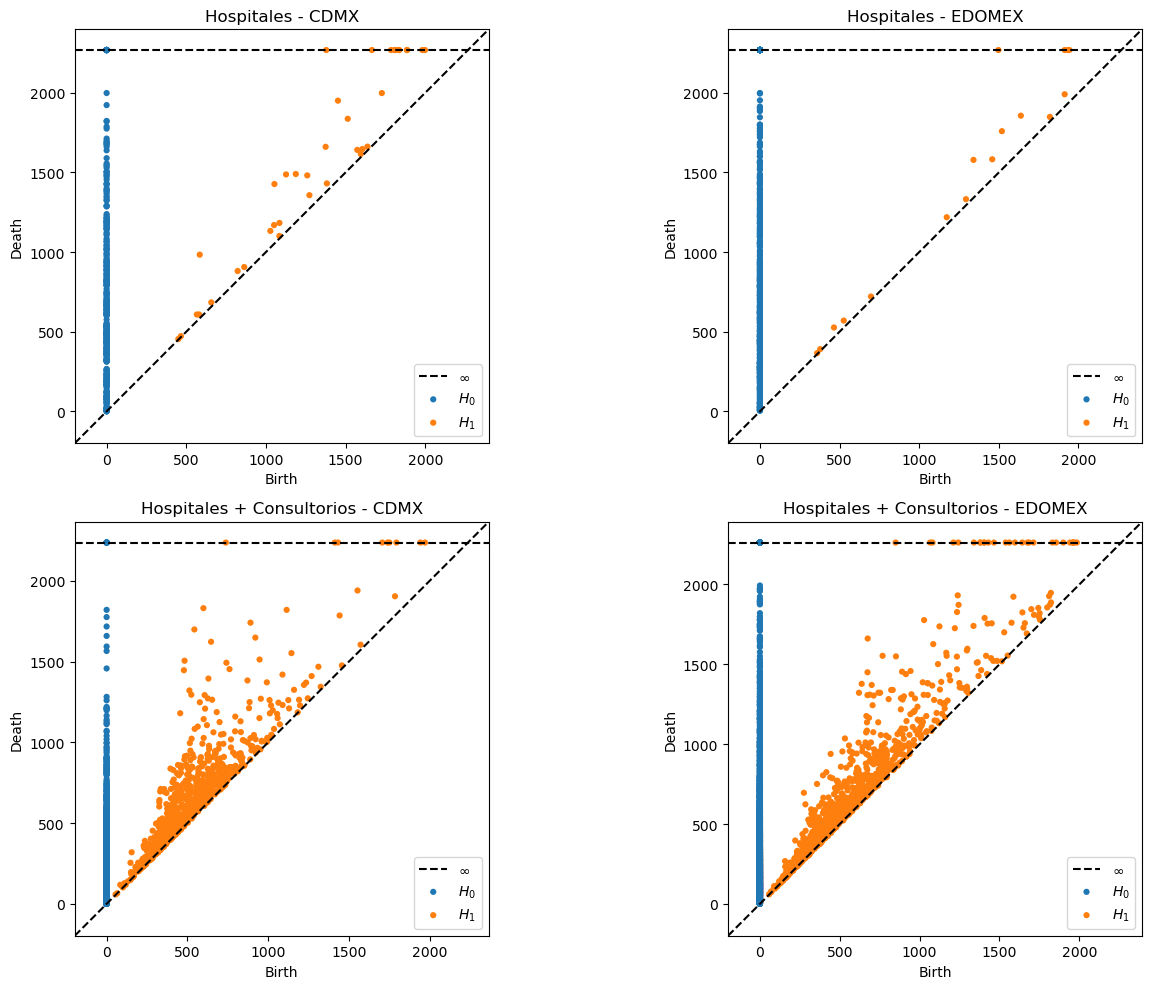

In [47]:
# al igual que antes se usa 2000
result_hosp_cdmx = ripser(points_hosp_cdmx, maxdim=1, thresh=2000)
result_hosp_edomex = ripser(points_hosp_edomex, maxdim=1, thresh=2000)
result_combinado_cdmx = ripser(points_combinado_cdmx, maxdim=1, thresh=2000)
result_combinado_edomex = ripser(points_combinado_edomex, maxdim=1, thresh=2000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# hospitales solos
axes[0,0].set_title("Hospitales - CDMX")
plt.sca(axes[0,0])
plot_diagrams(result_hosp_cdmx['dgms'], show=False)

axes[0,1].set_title("Hospitales - EDOMEX")
plt.sca(axes[0,1])
plot_diagrams(result_hosp_edomex['dgms'], show=False)

# combinado
axes[1,0].set_title("Hospitales + Consultorios - CDMX")
plt.sca(axes[1,0])
plot_diagrams(result_combinado_cdmx['dgms'], show=False)

axes[1,1].set_title("Hospitales + Consultorios - EDOMEX")
plt.sca(axes[1,1])
plot_diagrams(result_combinado_edomex['dgms'], show=False)

plt.tight_layout()
plt.show()

**CDMX**
En este caso, se observa que aún teniendo consultoríos, los huecos persistentes se mantienen. Es decir que la incorporación de consultoríos alrededor de la ciudad, no solventa la ausencia de hospitales en ciertas areás.

**EDOMEX**
En el caso del estado, se observa que hay un aumento en el número de huecos. Sin embargo, esto se puede deber a que existen municipios con falta de hospitales, mientras que si tienen consultorios. Es decir que el aumento de huecos, se debe a que el gráfico de persistensia de hospitales, no contabiliza a los municipios sin hospitales. Por ende, al añadir los consultoríos, se evidencia la desigualdad que existe en el estado, ya que hay zonas en donde los habitantes unicámente pueden ser atendidos mediante consultorios.

Por lo tanto, en el caso de la Ciudad de México, se observa que el número de huecos, no cambia al añadír consultorios. Empero, este no es el caso, para EDOMEX, ya que en este caso, hay zonas en dónde unicámente se tienen consultorios.

<Figure size 1000x500 with 0 Axes>

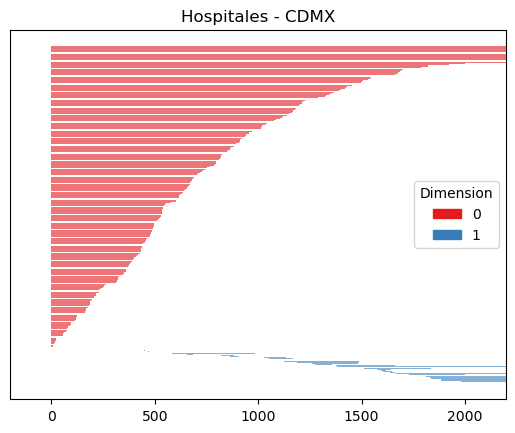

<Figure size 1000x500 with 0 Axes>

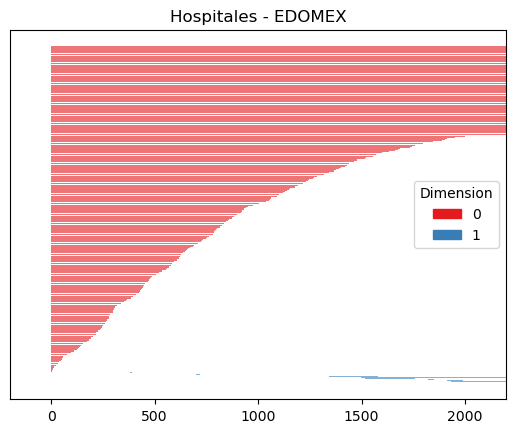

<Figure size 1000x500 with 0 Axes>

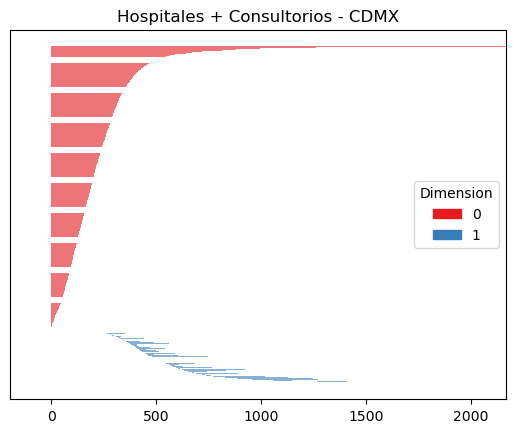

<Figure size 1000x500 with 0 Axes>

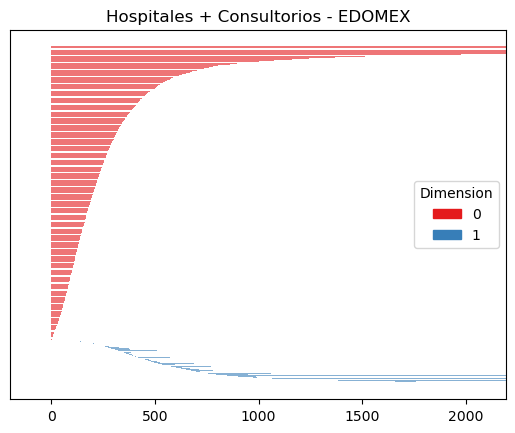

In [48]:

# Barcodes
simplex_hosp_cdmx = gd.RipsComplex(points=points_hosp_cdmx, max_edge_length=2000).create_simplex_tree(max_dimension=2)
simplex_hosp_edomex = gd.RipsComplex(points=points_hosp_edomex, max_edge_length=2000).create_simplex_tree(max_dimension=2)
simplex_comb_cdmx = gd.RipsComplex(points=points_combinado_cdmx, max_edge_length=2000).create_simplex_tree(max_dimension=2)
simplex_comb_edomex = gd.RipsComplex(points=points_combinado_edomex, max_edge_length=2000).create_simplex_tree(max_dimension=2)

for st, titulo in [
    (simplex_hosp_cdmx, "Hospitales - CDMX"),
    (simplex_hosp_edomex, "Hospitales - EDOMEX"),
    (simplex_comb_cdmx, "Hospitales + Consultorios - CDMX"),
    (simplex_comb_edomex, "Hospitales + Consultorios - EDOMEX")
]:
    st.compute_persistence()
    plt.figure(figsize=(10, 5))
    gd.plot_persistence_barcode(st.persistence(), legend=True)
    plt.title(titulo)
    plt.show()

**CDMX**
En este caso, se puede observar que existen huecos que persisten menos al agregar los consultoríos. Esto sugiere que los consultorios de una manera logran complementar a los servicios hospitalarios, pero siguen existiendo zonas con falta de acceso.

**EDOMEX**
En el caso de EDOMEX, se observa, cómo es que existe un aumento en el número de huecos. Por ende, esto evidencia la existencia de una desigualdad al acceso de hospitales en la el estado.

# Análisis hospitales y consultorios

Una vez, obtenidos los gráficos de persistencia, es posible identificar distintos hallazgos:
En la Ciudad de México, los huecos causador por la falta de hospitales, en algunas zonas, no son solventados por los consultoríos, ya que la distribución de estos siguen un patrón similar al de los hospitales. Por ende, existen alcaldías y zonas específicas, en dónde las personas, no tienen servicios médicos a menos de un radio de 2km, significando esto, en una límitante de acceso a servicios. En particular, durante el análisis, se encontró que las alcaldías, Milpa Alta, la Magdalena Contreras y Cuajímpalpa de Morelos, son las que menos accesibilidad tienen a servicios médicos. Mientras que Iztapalapa, Cuahtémoc y Gustavo A. Madero son las que más tienen. Esto sugiere un aréa de oportunidad para la ciudad, en dónde se tengan que incrementar los servicios médicos en las alcaldías mencionadas,

En el Estado de México, fue posible observar que los consultoríos médicos, no son capaces de disminuir el número de huecos. Al contrario, aparecen más, ya que existen municipios, que unicámente tienen consultorios y no tienen hospitales. Es decir que se evidencía la desigualdad que existe en cuestión de servicios médicos, ya que hay municipios, que unicámente cuentan con consultoríos médicos. Por ello, se recomienda focalizar estás zonas afectadas y encontrar maneras en las que se les pueda dar un servicio médico a al menos un radio de 2km, ya que de otra manera, estás personas, tendrían que trasladarse a diferentes partes del estado para poder ser atendidos. Esto debido a que fue posible identificar un caso de violencia estructural, dónde se le da servicio a ciertas zonas, mientras que a otras quedán no. Particularmente, se debe de centrar la atención en municipios cómo, San Simón de Guerrero, Santo Tomás y Timilpan. Asimismo, se recomienda que se incremente el número de atención en el oeste del estado.


In [49]:
# Guardar CSVs para análisis futuro
hosp_cdmx.to_csv('hospitales_cdmx.csv', index=False)
hosp_edomex.to_csv('hospitales_edomex.csv', index=False)
cons_cdmx.to_csv('consultorios_cdmx.csv', index=False)
cons_edomex.to_csv('consultorios_edomex.csv', index=False)

# K - means
Una vez que se realizo el análisis utilizando homología persistente, lo siguiente sera intentar encontrar diferentes hallazgos, utilizando K - means. Esto de manera en que se puedan comparar ambos métodos.

c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is k

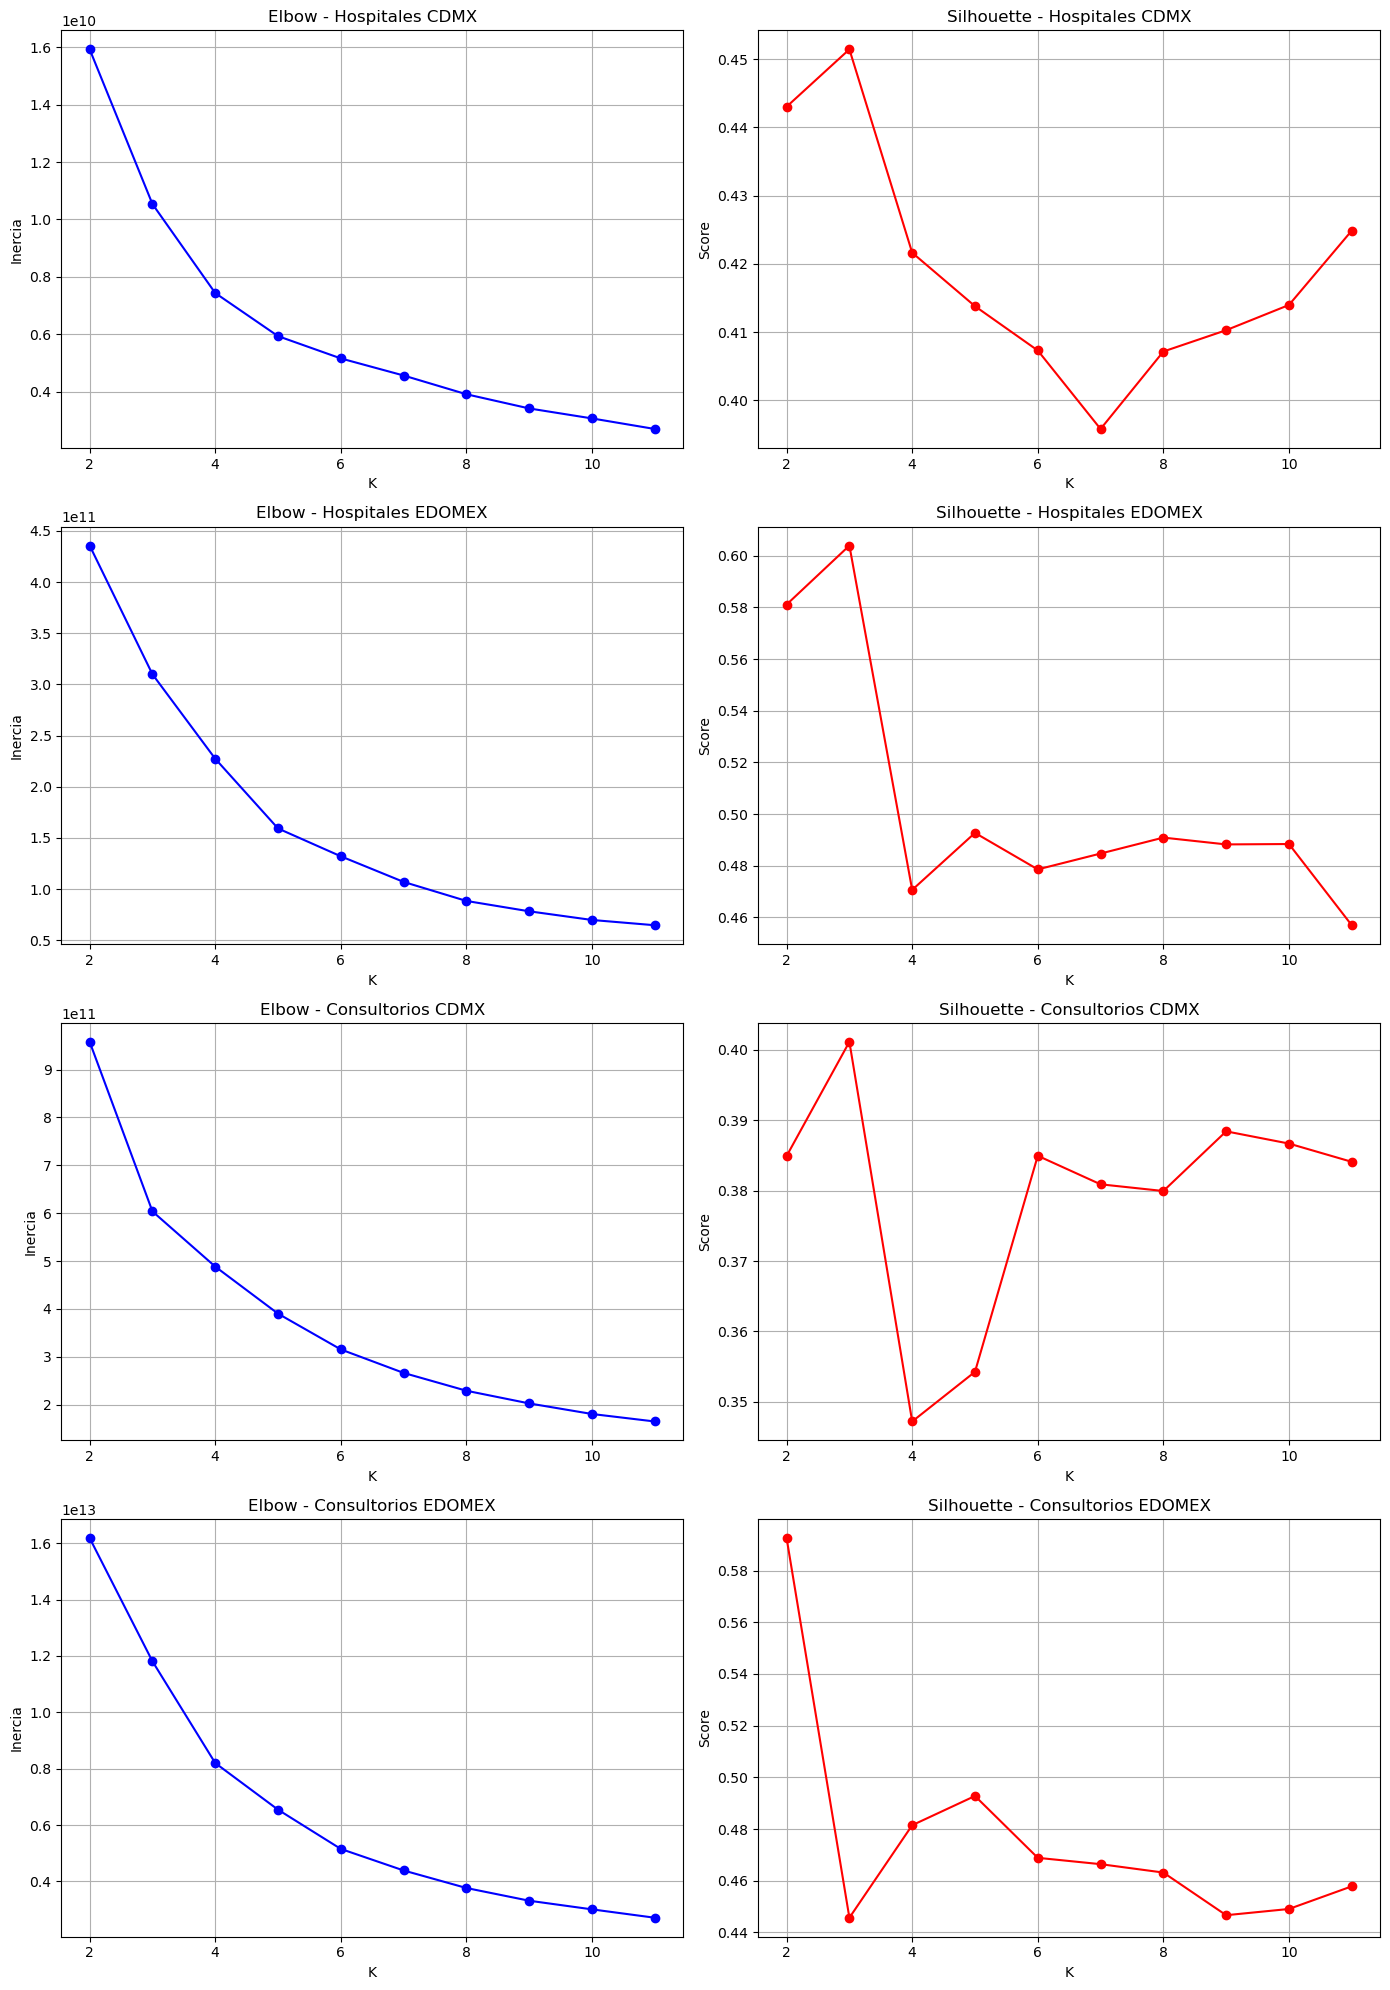

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Tomar los puntos de hospitales y consultorios por separado
datasets = {
    'Hospitales CDMX': points_hosp_cdmx,
    'Hospitales EDOMEX': points_hosp_edomex,
    'Consultorios CDMX': points_cons_cdmx,
    'Consultorios EDOMEX': points_cons_edomex,
}

# probar k de 2 a 11
K_range = range(2, 12)

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, (nombre, puntos) in enumerate(datasets.items()):
    inertias = []
    silhouettes = []

    for k in K_range:
        #  calcular inercia y silhouette para cada k
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(puntos)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(puntos, labels))

    # elbow plot
    axes[i, 0].plot(K_range, inertias, 'bo-')
    axes[i, 0].set_title(f'Elbow - {nombre}')
    axes[i, 0].set_xlabel('K')
    axes[i, 0].set_ylabel('Inercia')
    axes[i, 0].grid(True)

    # Silhouette
    axes[i, 1].plot(K_range, silhouettes, 'ro-')
    axes[i, 1].set_title(f'Silhouette - {nombre}')
    axes[i, 1].set_xlabel('K')
    axes[i, 1].set_ylabel('Score')
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

<!-- **CDMX**
Hospitales: la gráfica del codo indica que k debería de estar dentro del rango de 4-6. Mientras que el de silhoutte, muestra un decaimiento mayor a partir de 3 clusters. Por ende, se opta por tomar k = 4.
Consultorios: la gráfica del codo, muestra inclinación a partir de k = 5. De igual manera, en la gráfica de silhoutte hay un incrmento cuándo k = 5. Por ende se opta por tomar este valor.
Consultorios:

**EDOMEX**
Hospitales: en este caso, se observa que el codo es más promominente en k = 5 y que en la gráfica de silhoutte, hay un mayor decremento en k = 6 y 4. Por ende se opta por tomar k = 5.
Consultorios: al igual que los demás casos se opta por tomar k = 5, debido a la inclinación que hay en la gráfico del codo y al incremento que se muestra en el silhoutte score. -->

En todos los casos, se puede observar que el score de silhoutte más alto es 3, excepto por el caso de los consultorios en EDOMEX. Asimismo, el decaimiento de las gráficas de codo, en todos los casos, esta entre el intervalo 3-5. Es por esto que se opta por tomar k = 3.

c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


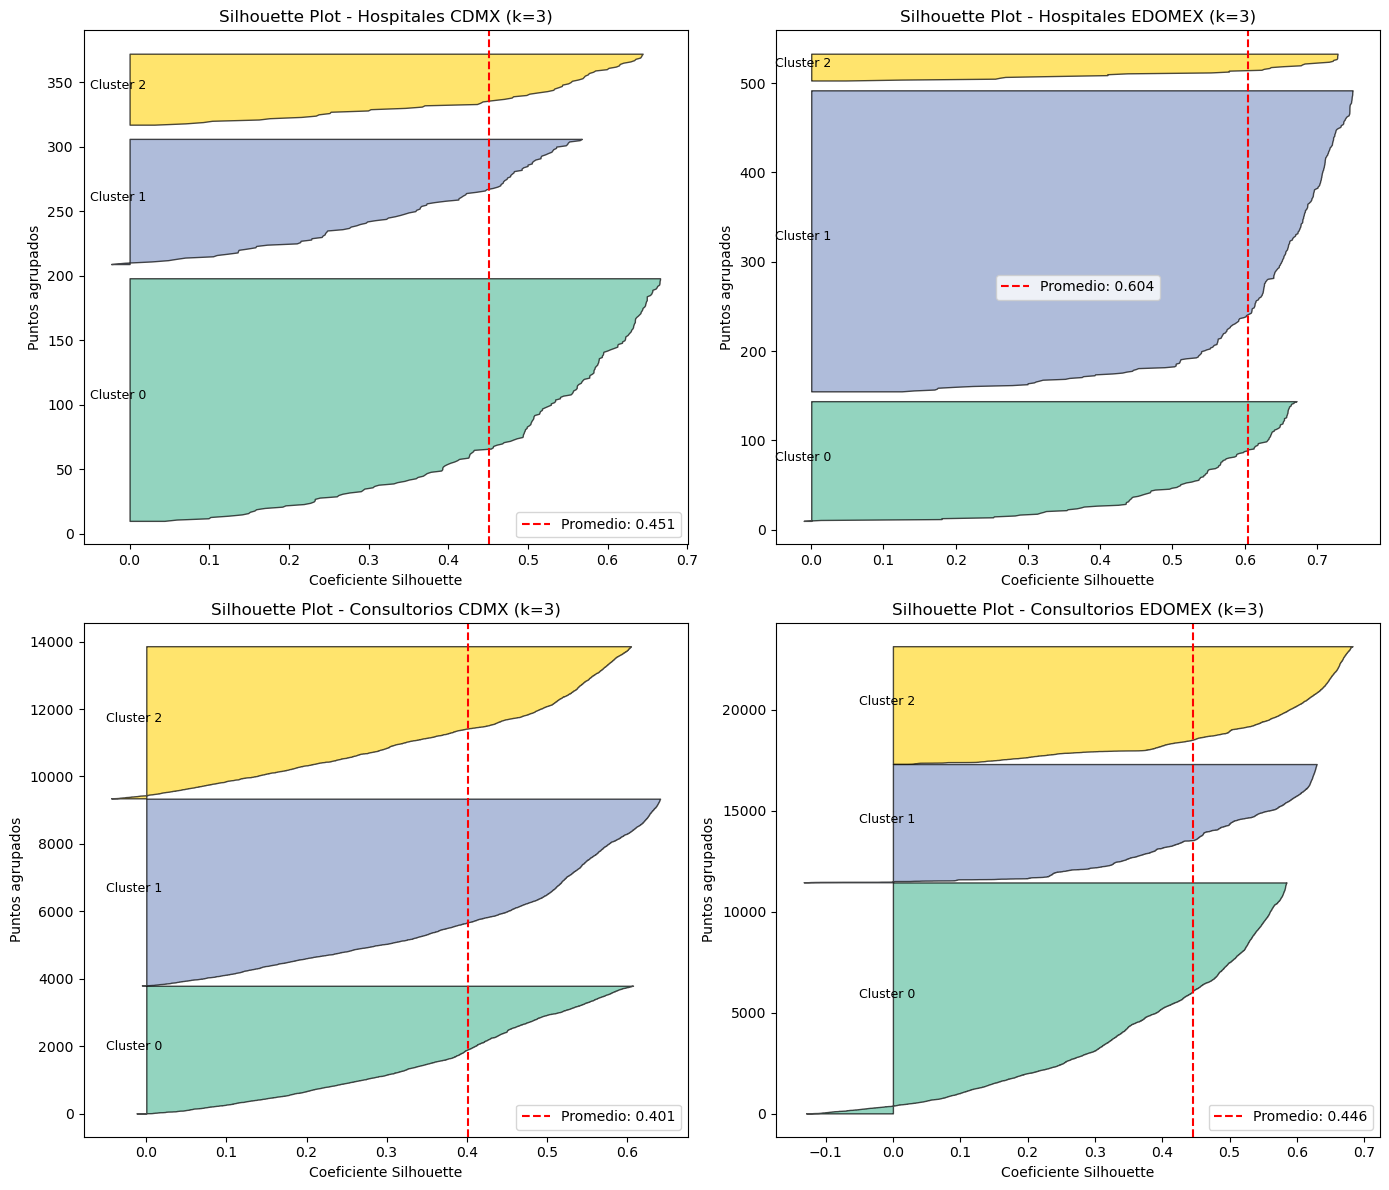

In [51]:
from sklearn.metrics import silhouette_samples, silhouette_score

# k seleccionado a partir de los gráficos anteriores
k_final = 3


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (nombre, puntos) in enumerate(datasets.items()):
    km = KMeans(n_clusters=k_final, random_state=42, n_init=10)
    # obtener etiquetas para cada punto
    labels = km.fit_predict(puntos)

    # calcular silhouette para cada punto y el promedio general
    sil_vals = silhouette_samples(puntos, labels)
    sil_avg = silhouette_score(puntos, labels)

    ax = axes[idx]
    y_lower = 10

    # para cada cluster, ordenar los silhouette values y graficarlos
    for i in range(k_final):
        vals_i = np.sort(sil_vals[labels == i])
        size_i = vals_i.shape[0]
        y_upper = y_lower + size_i

        color = plt.cm.Set2(i / k_final)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, vals_i,
            facecolor=color, edgecolor='black', alpha=0.7
        )
        ax.text(-0.05, y_lower + size_i / 2, f'Cluster {i}', fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(sil_avg, color='red', linestyle='--',
               label=f'Promedio: {sil_avg:.3f}')
    ax.set_title(f'Silhouette Plot - {nombre} (k={k_final})')
    ax.set_xlabel('Coeficiente Silhouette')
    ax.set_ylabel('Puntos agrupados')
    ax.legend()

plt.tight_layout()
plt.show()

**CDMX**
Hospitales: todos los clusters están bien definidos. El cluster 0, es el más ancho, indicando mejor separación. El cluster 1, tiene valores negativos, lo que sugiere que no logra separar los grupos completamente.
Consultorios: los grupos están bien definidos con tamaños similares entre clusters. Aunque el cluster 2 y 0, tiene valores negativos, sugiriendo puntos mal asignados.

**EDOMEX**
Hospitales: el cluster 1, es el más grande y mejor definido. Todos los clusters están por arriba del promedio.
Consultorios: el cluster 0 y 1, tienen valores negativos, lo que sugiere que existen puntos que no logran agruparse de manera correcta. En general, se puede inferir que los consultorios no forman grupos geográficos.

c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\pau_l\anaconda3\envs\IDM\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


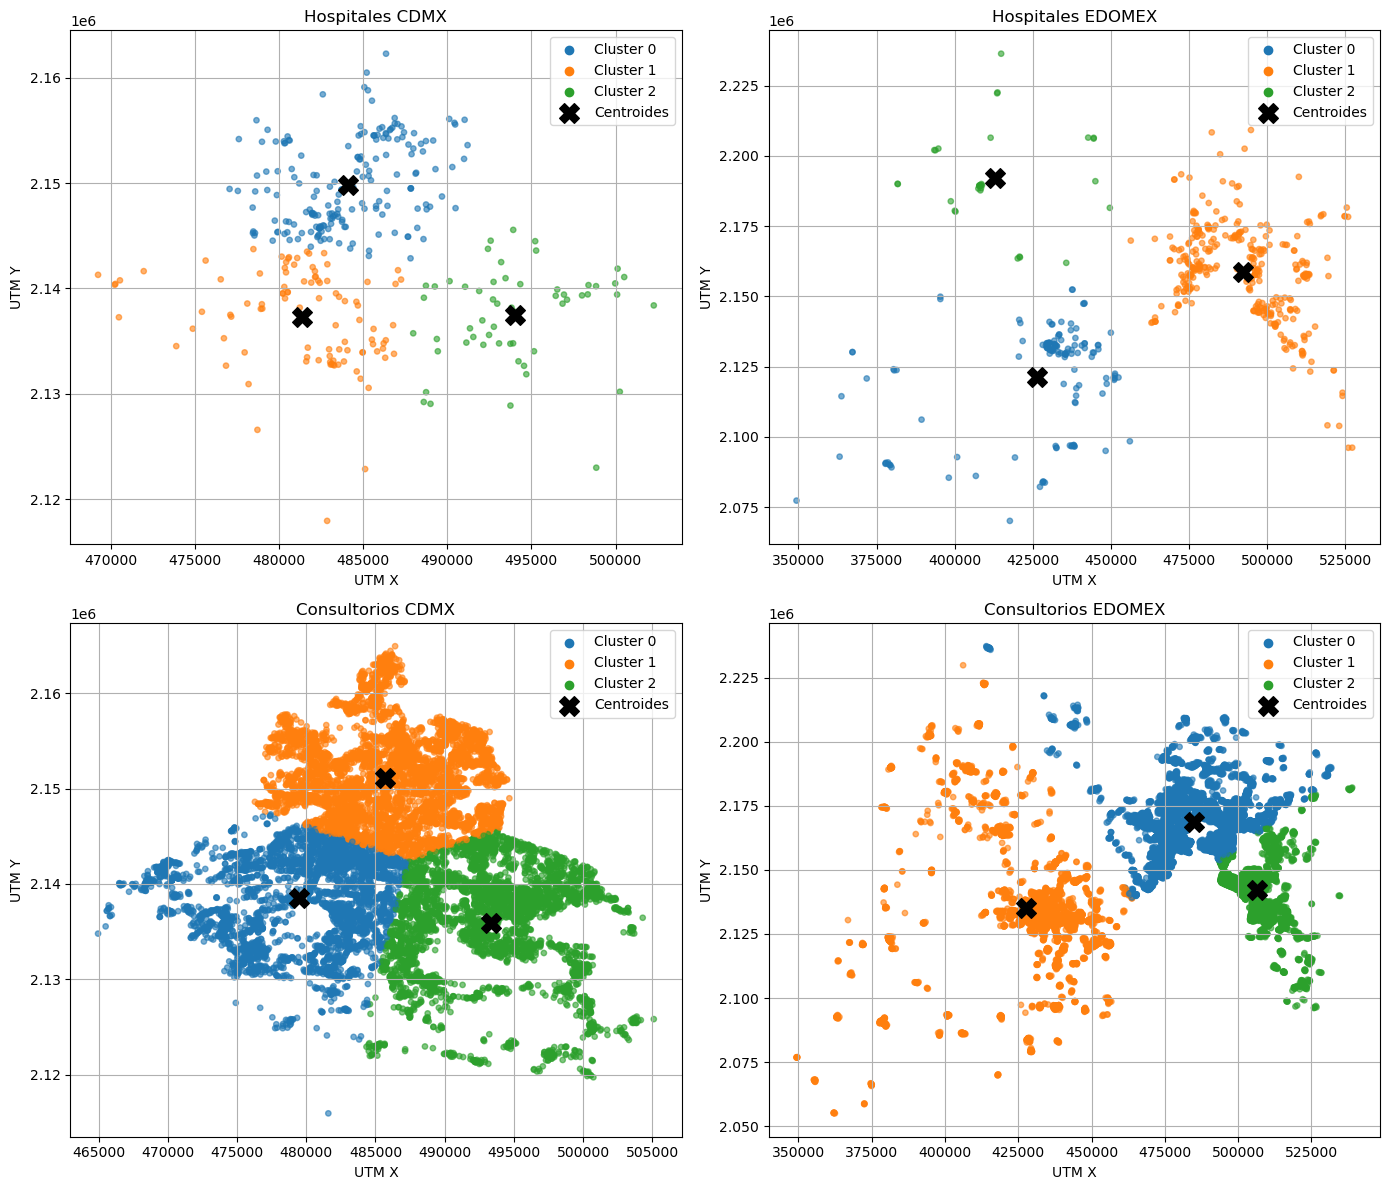


CDMX:
  Cluster 0: 189 puntos
  Cluster 1: 98 puntos
  Cluster 2: 56 puntos

EDOMEX:
  Cluster 0: 135 puntos
  Cluster 1: 338 puntos
  Cluster 2: 31 puntos

Consultorios CDMX:
  Cluster 0: 3785 puntos
  Cluster 1: 5538 puntos
  Cluster 2: 4512 puntos

Consultorios EDOMEX:
  Cluster 0: 11443 puntos
  Cluster 1: 5857 puntos
  Cluster 2: 5830 puntos


In [52]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

k = 3

# ── crear modelos y obtener etiquetas ─────────────────────────────
km_hosp_cdmx = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_hosp_cdmx = km_hosp_cdmx.fit_predict(points_hosp_cdmx)

km_hosp_edomex = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_hosp_edomex = km_hosp_edomex.fit_predict(points_hosp_edomex)

km_cons_cdmx = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_cons_cdmx = km_cons_cdmx.fit_predict(points_cons_cdmx)

km_cons_edomex = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_cons_edomex = km_cons_edomex.fit_predict(points_cons_edomex)

# ── Visualización ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, puntos, labels, km, titulo in zip(
    axes,
    [points_hosp_cdmx, points_hosp_edomex, points_cons_cdmx, points_cons_edomex],
    [labels_hosp_cdmx, labels_hosp_edomex, labels_cons_cdmx, labels_cons_edomex],
    [km_hosp_cdmx, km_hosp_edomex, km_cons_cdmx, km_cons_edomex],
    ['Hospitales CDMX', 'Hospitales EDOMEX', 'Consultorios CDMX', 'Consultorios EDOMEX']
):
    sc = ax.scatter(puntos[:, 0], puntos[:, 1],
                    c=labels, cmap='tab10', s=15, alpha=0.6, vmin=0, vmax=9)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='black', marker='X', s=200, zorder=5)

    # Leyenda con los colores exactos del cmap
    for i in range(k):
        ax.scatter([], [], color=plt.cm.tab10(i / 10), label=f'Cluster {i}')
    ax.scatter([], [], c='black', marker='X', s=200, label='Centroides')

    ax.set_title(titulo)
    ax.set_xlabel('UTM X')
    ax.set_ylabel('UTM Y')
    ax.legend()
    ax.grid(True)
    

plt.tight_layout()
plt.show()

# ── Tamaño de cada cluster
for nombre, labels in [('CDMX', labels_hosp_cdmx), ('EDOMEX', labels_hosp_edomex),
                        ('Consultorios CDMX', labels_cons_cdmx), ('Consultorios EDOMEX', labels_cons_edomex)]:
    print(f"\n{nombre}:")
    for i in range(k):
        print(f"  Cluster {i}: {(labels == i).sum()} puntos")

**CDMX**
Hospitales: la zona oeste de la ciudad, es la que tiene más puntos en comparación del resto. Se observa que los agrupamientos separan a la ciudad en tres zonas, bien definidad.
Consultorios: la zona sur de la capital es la que menos puntos tiene, siendo este parte del cluster 0 y 2.

**EDOMEX**
Hospitales: en este caso, también se pueden distinguir los hospitales por zonas en el estado, dónde el cluster 1, es el que más tiene hospitales, el cual corresponde a la zona oeste.
Consultorios: los consultorios están bien definidos y se puede observar que el cluster cero es el que más consultarios tiene a su disposición

In [53]:
# Agregar etiquetas de cluster a los DataFrames originales
hosp_cdmx = hosp_cdmx.copy()
hosp_cdmx['cluster'] = labels_hosp_cdmx

hosp_edomex = hosp_edomex.copy()
hosp_edomex['cluster'] = labels_hosp_edomex

cons_cdmx = cons_cdmx.copy()
cons_cdmx['cluster'] = labels_cons_cdmx
cons_edomex = cons_edomex.copy()
cons_edomex['cluster'] = labels_cons_edomex

In [54]:
# Hospitales por alcaldía/municipio
conteo_hosp_cdmx = hosp_cdmx.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_hosp_cdmx['total'] = conteo_hosp_cdmx.sum(axis=1)


conteo_hosp_edomex = hosp_edomex.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_hosp_edomex['total'] = conteo_hosp_edomex.sum(axis=1)

conteo_cons_cdmx = cons_cdmx.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_cons_cdmx['total'] = conteo_cons_cdmx.sum(axis=1)


conteo_cons_edomex = cons_edomex.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_cons_edomex['total'] = conteo_cons_edomex.sum(axis=1)

In [60]:
# Conteo por municipio
conteo_hosp_cdmx_mun = hosp_cdmx.groupby('municipio').size().rename('hospitales')
conteo_hosp_edomex_mun = hosp_edomex.groupby('municipio').size().rename('hospitales')
conteo_cons_cdmx_mun = cons_cdmx.groupby('municipio').size().rename('consultorios')
conteo_cons_edomex_mun = cons_edomex.groupby('municipio').size().rename('consultorios')

print("=== CDMX - Hospitales ===")
print(f"  Promedio: {conteo_hosp_cdmx_mun.mean():.1f}")
print(f"  Mínimo:   {conteo_hosp_cdmx_mun.min()} ({conteo_hosp_cdmx_mun.idxmin()})")
print(f"  Máximo:   {conteo_hosp_cdmx_mun.max()} ({conteo_hosp_cdmx_mun.idxmax()})")

print("\n=== EDOMEX - Hospitales ===")
print(f"  Promedio: {conteo_hosp_edomex_mun.mean():.1f}")
print(f"  Mínimo:   {conteo_hosp_edomex_mun.min()} ({conteo_hosp_edomex_mun.idxmin()})")
print(f"  Máximo:   {conteo_hosp_edomex_mun.max()} ({conteo_hosp_edomex_mun.idxmax()})")

print("\n=== CDMX - Consultorios ===")
print(f"  Promedio: {conteo_cons_cdmx_mun.mean():.1f}")
print(f"  Mínimo:   {conteo_cons_cdmx_mun.min()} ({conteo_cons_cdmx_mun.idxmin()})")
print(f"  Máximo:   {conteo_cons_cdmx_mun.max()} ({conteo_cons_cdmx_mun.idxmax()})")

print("\n=== EDOMEX - Consultorios ===")
print(f"  Promedio: {conteo_cons_edomex_mun.mean():.1f}")
print(f"  Mínimo:   {conteo_cons_edomex_mun.min()} ({conteo_cons_edomex_mun.idxmin()})")
print(f"  Máximo:   {conteo_cons_edomex_mun.max()} ({conteo_cons_edomex_mun.idxmax()})")


=== CDMX - Hospitales ===
  Promedio: 21.4
  Mínimo:   1 (Milpa Alta)
  Máximo:   60 (Cuauhtémoc)

=== EDOMEX - Hospitales ===
  Promedio: 5.2
  Mínimo:   1 (Acambay de Ruíz Castañeda)
  Máximo:   43 (Toluca)

=== CDMX - Consultorios ===
  Promedio: 864.7
  Mínimo:   227 (Milpa Alta)
  Máximo:   2546 (Iztapalapa)

=== EDOMEX - Consultorios ===
  Promedio: 185.0
  Mínimo:   1 (Ixtapan del Oro)
  Máximo:   2650 (Ecatepec de Morelos)


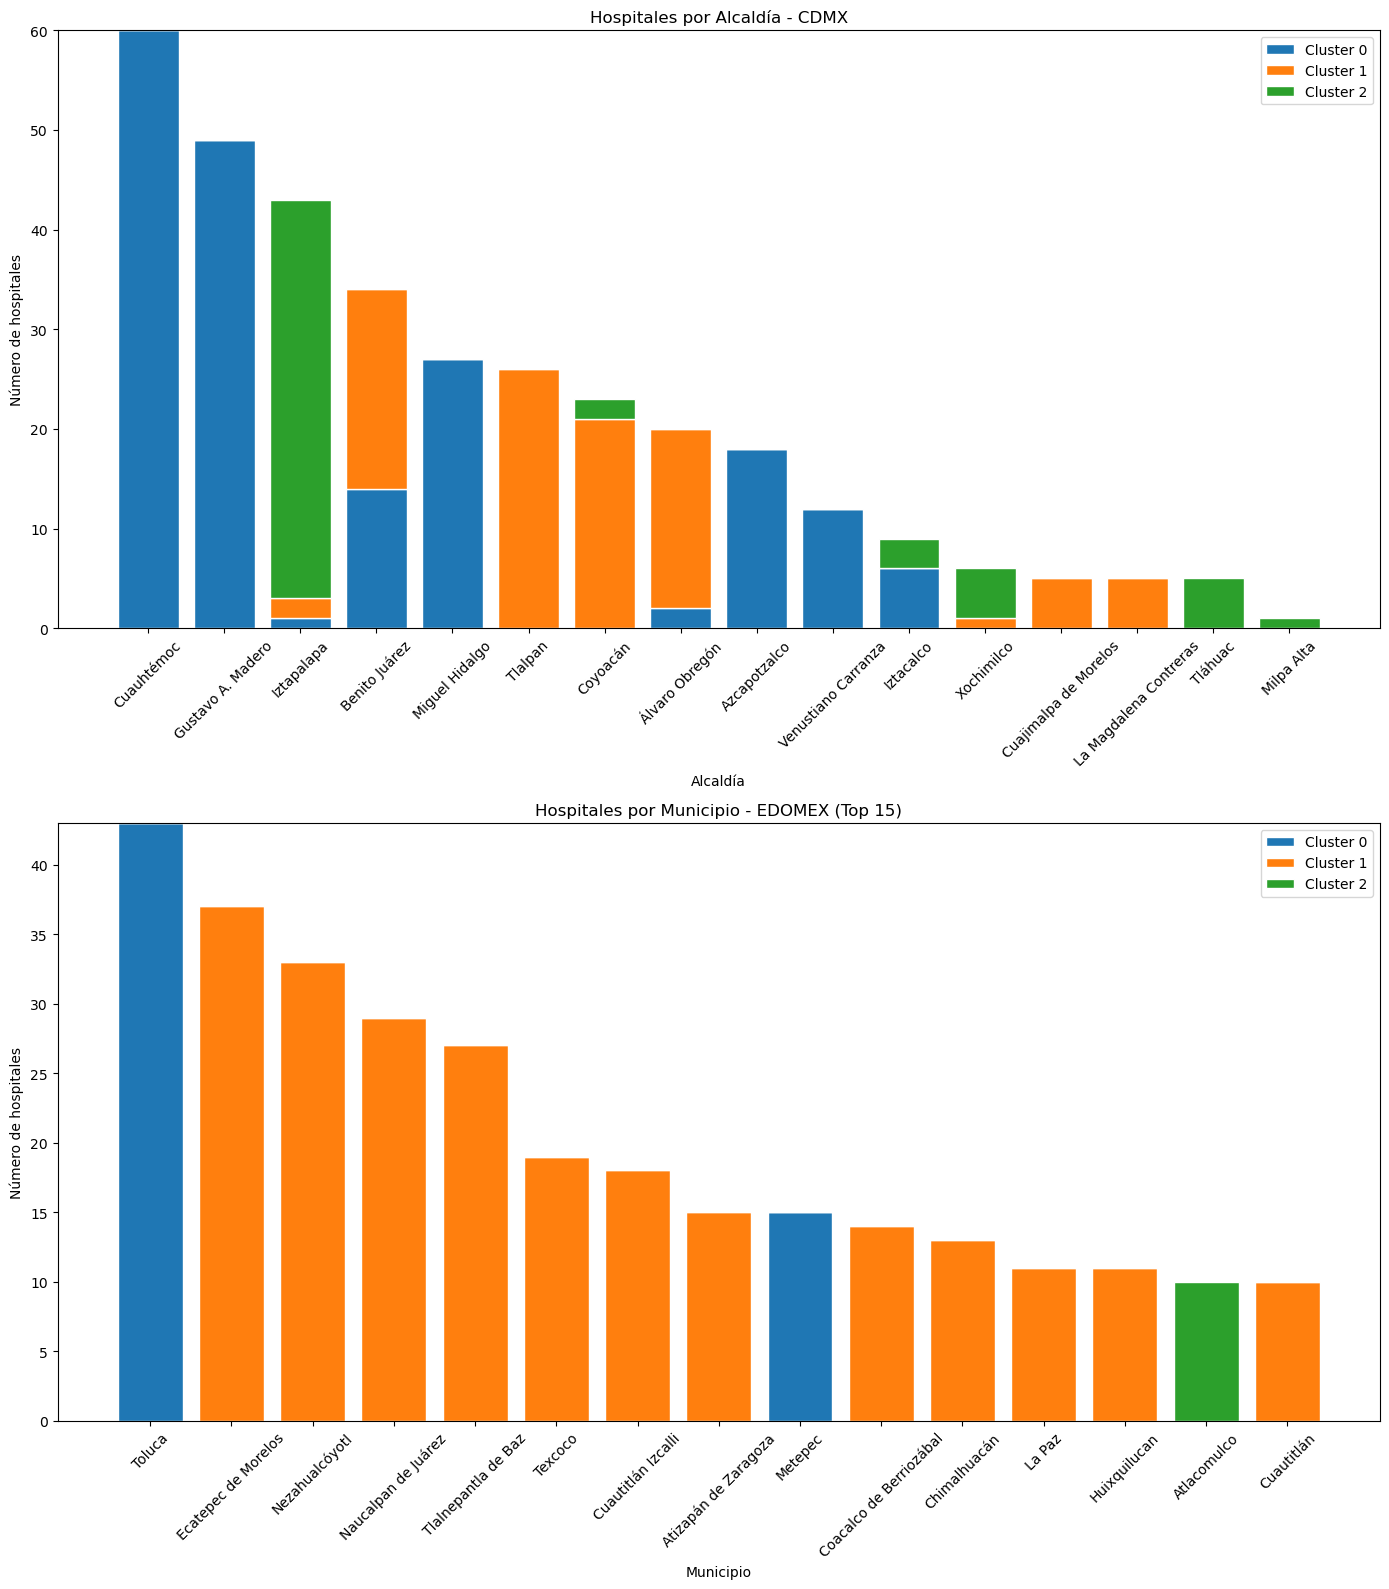

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# ── CDMX ────────────────────────────────────────────────────────
conteo_hosp_cdmx = hosp_cdmx.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_hosp_cdmx['total'] = conteo_hosp_cdmx.sum(axis=1)
conteo_hosp_cdmx = conteo_hosp_cdmx.sort_values('total', ascending=False)


# Hospitales por alcaldía - gráfico de barras apiladas
bottom = np.zeros(len(conteo_hosp_cdmx))
for i in range(k):
    if i in conteo_hosp_cdmx.columns:
        axes[0].bar(conteo_hosp_cdmx.index, conteo_hosp_cdmx[i],
                    bottom=bottom, color=plt.cm.tab10(i / 10),
                    label=f'Cluster {i}', edgecolor='white')
        bottom += conteo_hosp_cdmx[i].values

axes[0].set_title('Hospitales por Alcaldía - CDMX')
axes[0].set_xlabel('Alcaldía')
axes[0].set_ylabel('Número de hospitales')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# ── EDOMEX — top 15 municipios ──────────────────────────────────
conteo_hosp_edomex = hosp_edomex.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_hosp_edomex['total'] = conteo_hosp_edomex.sum(axis=1)
conteo_hosp_edomex = conteo_hosp_edomex.sort_values('total', ascending=False).head(15)

bottom = np.zeros(len(conteo_hosp_edomex))
for i in range(k):
    if i in conteo_hosp_edomex.columns:
        axes[1].bar(conteo_hosp_edomex.index, conteo_hosp_edomex[i],
                    bottom=bottom, color=plt.cm.tab10(i / 10),
                    label=f'Cluster {i}', edgecolor='white')
        bottom += conteo_hosp_edomex[i].values

axes[1].set_title('Hospitales por Municipio - EDOMEX (Top 15)')
axes[1].set_xlabel('Municipio')
axes[1].set_ylabel('Número de hospitales')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()


plt.tight_layout()
plt.show()

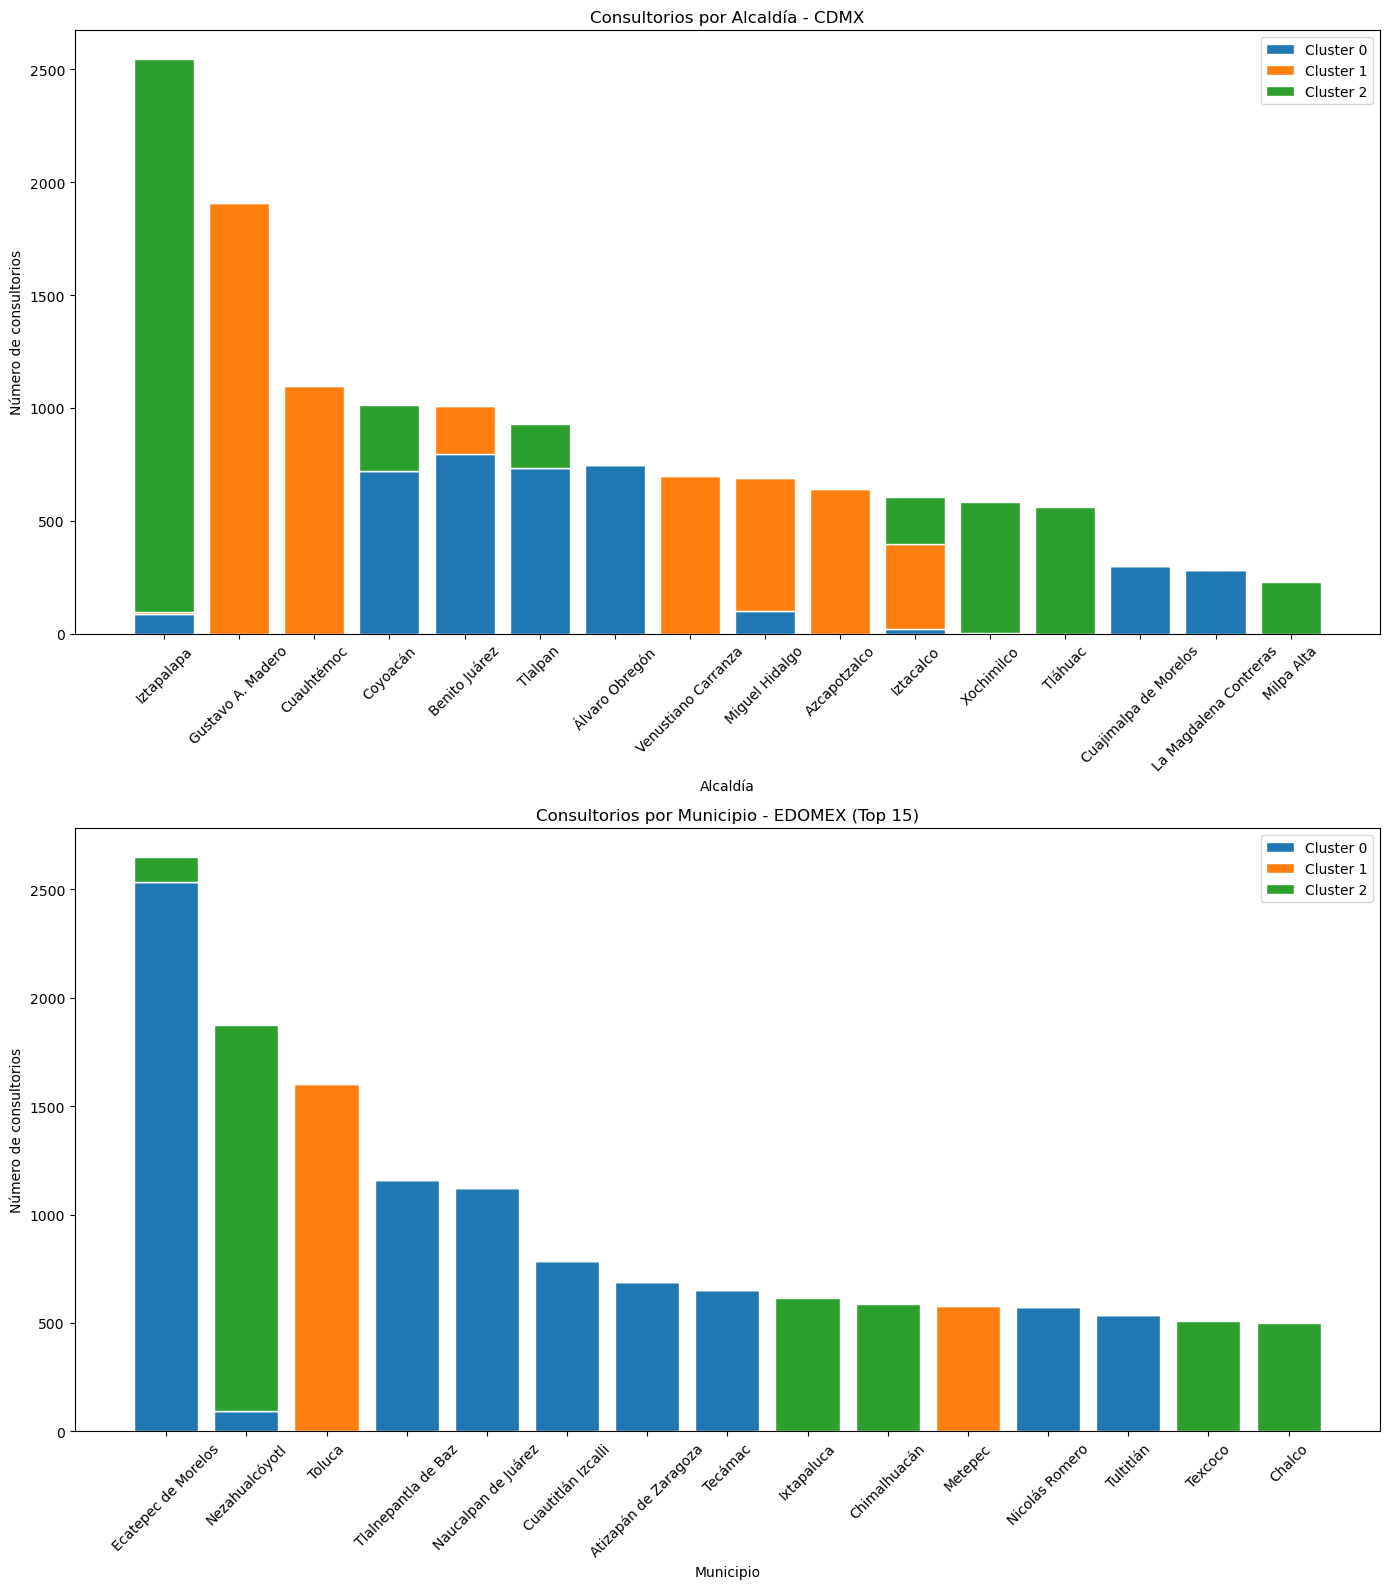

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# ── CDMX ────────────────────────────────────────────────────────
conteo_cons_cdmx = cons_cdmx.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_cons_cdmx['total'] = conteo_cons_cdmx.sum(axis=1)
conteo_cons_cdmx = conteo_cons_cdmx.sort_values('total', ascending=False)

bottom = np.zeros(len(conteo_cons_cdmx))
for i in range(k):
    if i in conteo_cons_cdmx.columns:
        axes[0].bar(conteo_cons_cdmx.index, conteo_cons_cdmx[i],
                    bottom=bottom, color=plt.cm.tab10(i / 10),
                    label=f'Cluster {i}', edgecolor='white')
        bottom += conteo_cons_cdmx[i].values

axes[0].set_title('Consultorios por Alcaldía - CDMX')
axes[0].set_xlabel('Alcaldía')
axes[0].set_ylabel('Número de consultorios')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()


# ── EDOMEX — top 15 municipios ──────────────────────────────────
conteo_cons_edomex = cons_edomex.groupby(['municipio', 'cluster']).size().unstack(fill_value=0)
conteo_cons_edomex['total'] = conteo_cons_edomex.sum(axis=1)
conteo_cons_edomex = conteo_cons_edomex.sort_values('total', ascending=False).head(15)

bottom = np.zeros(len(conteo_cons_edomex))
for i in range(k):
    if i in conteo_cons_edomex.columns:
        axes[1].bar(conteo_cons_edomex.index, conteo_cons_edomex[i],
                    bottom=bottom, color=plt.cm.tab10(i / 10),
                    label=f'Cluster {i}', edgecolor='white')
        bottom += conteo_cons_edomex[i].values

axes[1].set_title('Consultorios por Municipio - EDOMEX (Top 15)')
axes[1].set_xlabel('Municipio')
axes[1].set_ylabel('Número de consultorios')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()


plt.tight_layout()
plt.show()

**Hospitales**

Cluster 0: Cuauhtémoc, Gustavo A. Madero, Iztapalapa, Benito Juárez, Miguel Hidalgo, Álvaro Obregón, Azcapotzalco, Venustiano Carranza, Iztacalco.

Estos hospitales están en el área centro-norte de la ciudad. Mayormente en Cuauhtémoc, Gustavo A. Madero, Miguel Hidalgo, Azcapotzalco y Venustiano Carranza. En cuánto a este grupo, se puede observar, que tiene dos de las alcaldías con mayor acceso a hospitales. Además de que todas las alcaldías en este grupo, excepto por Iztacalco, tienen más de 10 hospitales en el área. Por ende se infiere que este grupo, representa a aquellas alcaldías con mayor acceso médico.

Cluster 1: Iztapalapa, Benito Juárez, Tlalpan, Coyoacán, Álvaro Obregón, Xochimilco, Cuajimalpa de Morelos, Magdalena Contreras.

Estos hospitales están distribuidos alrededor del centro-sur, poniente y oriente de la capital. Dónde mayormente se encuentran en Tlalpan, Cuajimalpa de Morelos, Coyoacán, Benito Juárez y Álvaro Obregón.

La mayoría de las alcaldías que se encuentran dentro de este cluster tiene aproximadamente 20 hospitales, con excepción de Cuajimalpa de Morelos y Magdalena Contreras. Por lo tanto, se interpreta que estas zonas de la ciudad, tienen acceso moderado a servicios médicos.


Cluster 2: Iztapalapa, Coyoacán, Iztacalco, Xochimilco, Tláhuac, Milpa Alta

Estos hospitales se encuentran al oriente de la ciudad. A excepción de Iztapalapa, las alcaldías que están en este cluster, tienen menos de diez hospitales. Por ende, se identifica que grupo de puntos, representan a las zonas con menor acceso a salud, ya que está por debajo del promedio de número de hospitales. A excepción de Iztapalapa, ya que es la tercera alcaldía con más hospitales.


Aunado a esto, ya que hay 125 municipios en el Estado de México, se optó por únicamente observar aquellos que tengan más hospitales y los que tengan menos.

La mayoría de los municipios con más hospitales, pertenecen al cluster 1. Dónde se encuentran municipios como Ecatepec de Morelos, Nezahualcóyotl, Naucalpan de Juárez, Tlalnepantla de Baz, entre otros. Asimismo, es posible identificar que la capital de EDOMEX, Toluca es la que más hospitales tiene y pertenece al cluster 1, así como Metepec. Por su parte, únicamente, se identificó al municipio de Atlacomulco como municipio dentro del cluster 2. Por lo tanto, los municipios con mayor acceso a hospitales, se encuentran al este del Estado y corresponden al cluster 1.

Asimismo, en la gráfica del mapa, es posible identificar que la zona con menor acceso médico, se encuentra en la región del norte y corresponde al cluster 2. Mientras que la zona suroeste, corresponde al cluster 0, dónde hay mayor concentración de hospitales, en Toluca y municipios a su alrededor.

Cabe mencionar, que la concentración de hospitales, es mayor en los municipios que se encuentran más cercanos a la Ciudad de México, entre más alejados estén menos puntos hay. Esto sugiere que existe una desigualdad en la distribución de servicios médicos, ya que las periferias del Estado de México, no cuentan con el mismo acceso a hospitales.


**Consultorios**

En la Ciudad de México, es posible observar que así como la mayoría de los hospitales, se encontraban dentro del área centro-norte de la ciudad, en este caso también. Sin embargo, a diferencia de los hospitales, en este caso, el área que tienen menos consultorios es la del oriente de la ciudad. Por ende, a diferencia del caso anterior, dónde la zona con menos hospitales era el oriente de la ciudad, en este caso se observa que hay más consultorios, con lo que se puede inferir, que a pesar de no tener muchos hospitales, las personas, pueden acudir a estos servicios para ser atendidos. 

Sin embargo, es importante destacar que durante el análisis de homología se observó que aún teniendo consultorios, el número de huecos no disminuye. Por lo que, a pesar de que en el análisis de clustering indica que los habitantes de esas zonas, tienen más consultorios en lugar de hospitales, y que podrían ser atendidos ahí, se identificó que aún así perduran las áreas en dónde existen huecos.

En el caso del Estado de México, se observa que el área norte, que era la que menos hospitales tenía, es la que más consultorios tiene. Por lo que se confirma lo antes visto en el análisis de homología, dónde las zonas sin hospitales, cuentan con consultorios y otros servicios médicos, lo cual sugiere que existe una desigualdad en el acceso a servicios médicos, ya que estas zonas, no cuentan con acceso hospitales. Asimismo, cabe mencionar que a pesar de la existencia de consultorios, estos no logran solventar los huecos que existen en el estado. 

De igual manera, se encontró que al este del Estado de México, hay menos consultorios que en el resto del estado. Es decir que el área dónde hay mayor servicio hospitalario es el que menos requiere de consultorios. 



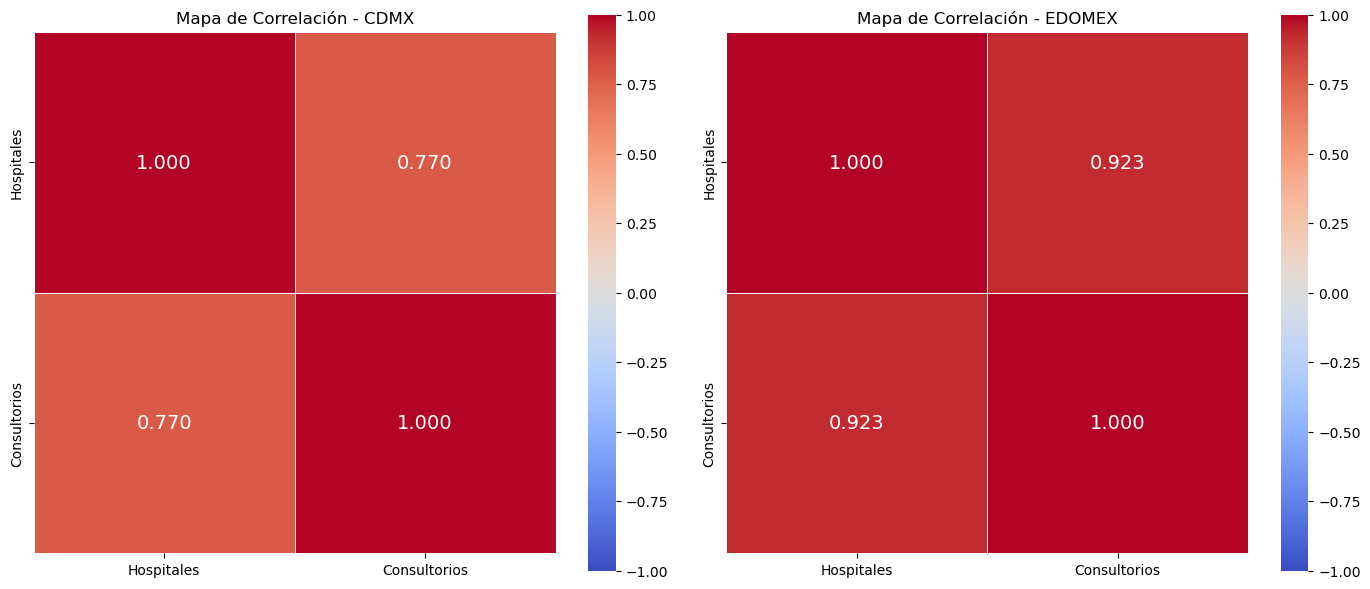

In [59]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, h_df, c_df, titulo in zip(
    axes,
    [hosp_cdmx, hosp_edomex],
    [cons_cdmx, cons_edomex],
    ['CDMX', 'EDOMEX']
):
    conteo_hosp = h_df.groupby('municipio').size().rename('Hospitales')
    conteo_cons = c_df.groupby('municipio').size().rename('Consultorios')

    df_corr = pd.concat([conteo_hosp, conteo_cons], axis=1).fillna(0)

    corr_matrix = df_corr.corr()

    sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.3f',
                cmap='coolwarm', vmin=-1, vmax=1,
                square=True, linewidths=0.5,
                annot_kws={'size': 14})

    ax.set_title(f'Mapa de Correlación - {titulo}')

plt.tight_layout()
plt.show()